# 1,SETUP

In [1]:
libraries = [
    "xgboost",
    "lightgbm",
    "imblearn",      
    "optuna",
    "sklearn",      
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn"
]

for lib in libraries:
    try:
        __import__(lib)
        print(f"{lib}: ✅ Installed & import OK")
    except ImportError:
        print(f"{lib}: ❌ NOT installed")

xgboost: ✅ Installed & import OK
lightgbm: ✅ Installed & import OK
imblearn: ✅ Installed & import OK
optuna: ✅ Installed & import OK
sklearn: ✅ Installed & import OK
pandas: ✅ Installed & import OK
numpy: ✅ Installed & import OK
matplotlib: ✅ Installed & import OK
seaborn: ✅ Installed & import OK


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, fbeta_score, make_scorer
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier, XGBRFClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Constants ──────────────────────────────────────────────────────────────────
RANDOM_STATE  = 42
N_SPLITS      = 10
N_SPLITS_TUNE = 5
CLASS_NAMES   = ['High', 'Low', 'Medium']   # 0=High, 1=Low, 2=Medium
BASELINE_F2   = 0.9437   # XGBoost raw v1 — target cần beat

f2_macro_scorer    = make_scorer(fbeta_score, beta=2, average='macro',   zero_division=0)
f1_weighted_scorer = make_scorer(f1_score,           average='weighted', zero_division=0)
f1_macro_scorer    = make_scorer(f1_score,           average='macro',    zero_division=0)
precision_macro_scorer = make_scorer(precision_score, average='macro', zero_division=0)
recall_macro_scorer    = make_scorer(recall_score,    average='macro', zero_division=0)

palette = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
print('✅ Setup done')

✅ Setup done


In [3]:
# ── Load train.csv và test.csv ─────────────────────────────────────────────────
# train.csv: 2370 rows — dùng để TRAIN model
# test.csv : 593  rows — chỉ dùng để EVALUATE (không được nhìn trong quá trình train/tune)

train_df = pd.read_csv('/kaggle/input/datasets/cdnghnam/mlproject-data/train.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/cdnghnam/mlproject-data/test.csv')

print(f'Train : {train_df.shape[0]:,} rows × {train_df.shape[1]} cols  (dùng để TRAIN)')
print(f'Test  : {test_df.shape[0]:,}  rows × {test_df.shape[1]} cols  (dùng để TEST — chỉ evaluate cuối)')
print()
print('Encoding của target:')
enc_check = train_df[['risk_class','risk_class_encoded']].drop_duplicates().sort_values('risk_class_encoded')
print(enc_check.to_string(index=False))
train_df.head()

Train : 2,370 rows × 16 cols  (dùng để TRAIN)
Test  : 593  rows × 16 cols  (dùng để TEST — chỉ evaluate cuối)

Encoding của target:
risk_class  risk_class_encoded
      High                   0
       Low                   1
    Medium                   2


,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years,is_very_low_elev,rain_x_return,land_use,soil_group,storm_drain_type,rainfall_source,dem_source,risk_class,risk_class_encoded,latitude,longitude
0,32.67,7.87,140.0,19.9,10,0,199.0,6.0,0.0,0.0,3.0,4.0,Low,1,38.853632,-77.017289
1,33.82,4.67,60.6,48.0,5,0,240.0,1.0,1.0,1.0,4.0,3.0,Low,1,21.065060,105.831464
2,19.82,6.26,282.2,74.3,5,0,371.5,0.0,0.0,3.0,3.0,1.0,Low,1,22.633800,113.957179
3,7.71,6.32,47.9,41.1,2,0,82.2,6.0,0.0,1.0,1.0,4.0,Medium,2,41.393959,2.143102
4,12.56,9.53,117.6,23.1,100,0,2310.0,2.0,0.0,1.0,1.0,0.0,Low,1,31.350399,121.515148


In [4]:
# ── Định nghĩa features & target ──────────────────────────────────────────────
TARGET = 'risk_class_encoded'   # 0=High, 1=Low, 2=Medium

NUM_FEATURES = [
    'elevation_m',
    'drainage_density_km_per_km2',
    'storm_drain_proximity_m',
    'historical_rainfall_intensity_mm_hr',
    'return_period_years',
    'is_very_low_elev',    # engineered: 1 nếu elevation < 5m
    'rain_x_return',       # engineered: rainfall × return_period
    'latitude',
    'longitude',
]

CAT_FEATURES = [
    'land_use',
    'soil_group',
    'storm_drain_type',
    'rainfall_source',
    'dem_source',
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

# ── Train / Test split ─────────────────────────────────────────────────────────
X_train = train_df[ALL_FEATURES].copy()   # features dùng để TRAIN
y_train = train_df[TARGET].copy()         # labels dùng để TRAIN

X_test  = test_df[ALL_FEATURES].copy()    # features dùng để TEST
y_test  = test_df[TARGET].copy()          # labels để evaluate

print('Class distribution — TRAIN (dùng để train model):')
vc_train = train_df['risk_class'].value_counts()
for cls in ['Low','Medium','High']:
    pct = vc_train[cls] / len(train_df) * 100
    print(f'  {cls:<8}: {vc_train[cls]:>5} ({pct:.1f}%)')

print('\nClass distribution — TEST (chỉ dùng để evaluate):')
vc_test = test_df['risk_class'].value_counts()
for cls in ['Low','Medium','High']:
    pct = vc_test[cls] / len(test_df) * 100
    print(f'  {cls:<8}: {vc_test[cls]:>5} ({pct:.1f}%)')

print(f'\nImbalance ratio Low/High (train): {vc_train["Low"]/vc_train["High"]:.2f}x')
print(f'X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}')

Class distribution — TRAIN (dùng để train model):
  Low     :  1595 (67.3%)
  Medium  :   459 (19.4%)
  High    :   316 (13.3%)

Class distribution — TEST (chỉ dùng để evaluate):
  Low     :   399 (67.3%)
  Medium  :   115 (19.4%)
  High    :    79 (13.3%)

Imbalance ratio Low/High (train): 5.05x
X_train shape: (2370, 14)  |  X_test shape: (593, 14)


In [5]:
def add_g3(df):
    df = df.copy()
    # G3a: soil D (khó thấm) + mưa lớn = runoff max
    df['G3_effective_runoff'] = (
        df['historical_rainfall_intensity_mm_hr'] *
        (df['soil_group'].astype(float) + 1)
    ) / 4.0
    # G3b: soil D + vùng thấp = worst case
    df['G3_soil_elev_risk'] = (
        (df['soil_group'].astype(float) + 1) /
        (df['elevation_m'].clip(lower=0.5) + 1)
    )
    return df

train_df = add_g3(train_df)
test_df  = add_g3(test_df)

G3_FEATURES    = ['G3_effective_runoff', 'G3_soil_elev_risk']
ALL_FEAT_G3    = ALL_FEATURES + G3_FEATURES
CAT_INDICES_G3 = [ALL_FEAT_G3.index(f) for f in CAT_FEATURES]

X_train_g3 = train_df[ALL_FEAT_G3].copy()
X_test_g3  = test_df[ALL_FEAT_G3].copy()

print(f'Baseline : {len(ALL_FEATURES)} features')
print(f'+G3      : {len(ALL_FEAT_G3)} features')

print('\nG3_effective_runoff per class:')
print(train_df.groupby('risk_class')['G3_effective_runoff']
      .agg(['mean','median']).round(2))
sp, _ = stats.spearmanr(train_df['G3_effective_runoff'], y_train)
print(f'\nSpearman G3_effective_runoff vs target: {sp:.4f}')

Baseline : 14 features
+G3      : 16 features

G3_effective_runoff per class:
             mean  median
risk_class               
High        65.54   60.10
Low         26.19   21.35
Medium      24.15   18.80

Spearman G3_effective_runoff vs target: -0.3395


In [6]:
# Sample weights cho fit() — dùng khi model không có class_weight param
sample_weights_train = compute_sample_weight('balanced', y_train)

# Class weight dict cho các model hỗ trợ
unique_classes, counts = np.unique(y_train, return_counts=True)
class_weight_dict = {
    cls: len(y_train) / (len(unique_classes) * cnt)
    for cls, cnt in zip(unique_classes, counts)
}
# XGBoost scale_pos_weight chỉ dùng cho binary
# → với multiclass dùng sample_weight trong fit()
print('Class weight dict:', {CLASS_NAMES[k]: round(v,3) for k,v in class_weight_dict.items()})
print(f'Weight ratio High/Low: {class_weight_dict[0]/class_weight_dict[1]:.2f}x')

Class weight dict: {'High': np.float64(2.5), 'Low': np.float64(0.495), 'Medium': np.float64(1.721)}
Weight ratio High/Low: 5.05x


# 2.EDA

In [7]:
# ── 2.2 Thống kê mô tả ────────────────────────────────────────────────────────
train_df[NUM_FEATURES].describe().round(3)

,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years,is_very_low_elev,rain_x_return,latitude,longitude
count,2370.000,2370.000,2370.000,2370.000,2370.000,2370.000,2370.000,2370.000,2370.000
mean,39.907,6.302,115.382,43.822,19.741,0.085,1030.490,19.472,30.752
std,35.566,2.056,89.543,25.172,25.360,0.279,1813.057,24.397,79.610
min,-2.960,1.270,0.200,6.000,2.000,0.000,13.200,-36.966,-123.271
25%,14.612,4.860,50.900,25.700,5.000,0.000,120.575,6.521,-43.166
50%,30.025,6.260,91.400,38.200,10.000,0.000,304.250,23.761,36.836
75%,56.022,7.660,153.175,55.600,25.000,0.000,1111.875,37.897,101.702
max,266.700,12.070,339.775,150.000,100.000,1.000,15000.000,55.821,174.911


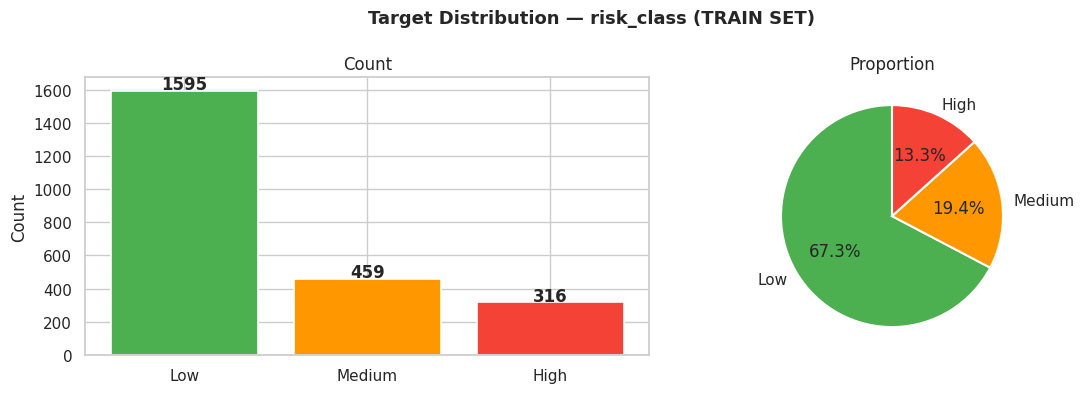

In [8]:
# ── 2.3 Target distribution ────────────────────────────────────────────────────
palette = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
order   = ['Low', 'Medium', 'High']
counts  = [vc_train[c] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(order, counts, color=[palette[c] for c in order], edgecolor='white', lw=1.2)
for i, v in enumerate(counts):
    axes[0].text(i, v+8, str(v), ha='center', fontweight='bold')
axes[0].set_title('Count', fontsize=12)
axes[0].set_ylabel('Count')

axes[1].pie(counts, labels=order, autopct='%1.1f%%',
            colors=[palette[c] for c in order], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Proportion', fontsize=12)

plt.suptitle('Target Distribution — risk_class (TRAIN SET)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

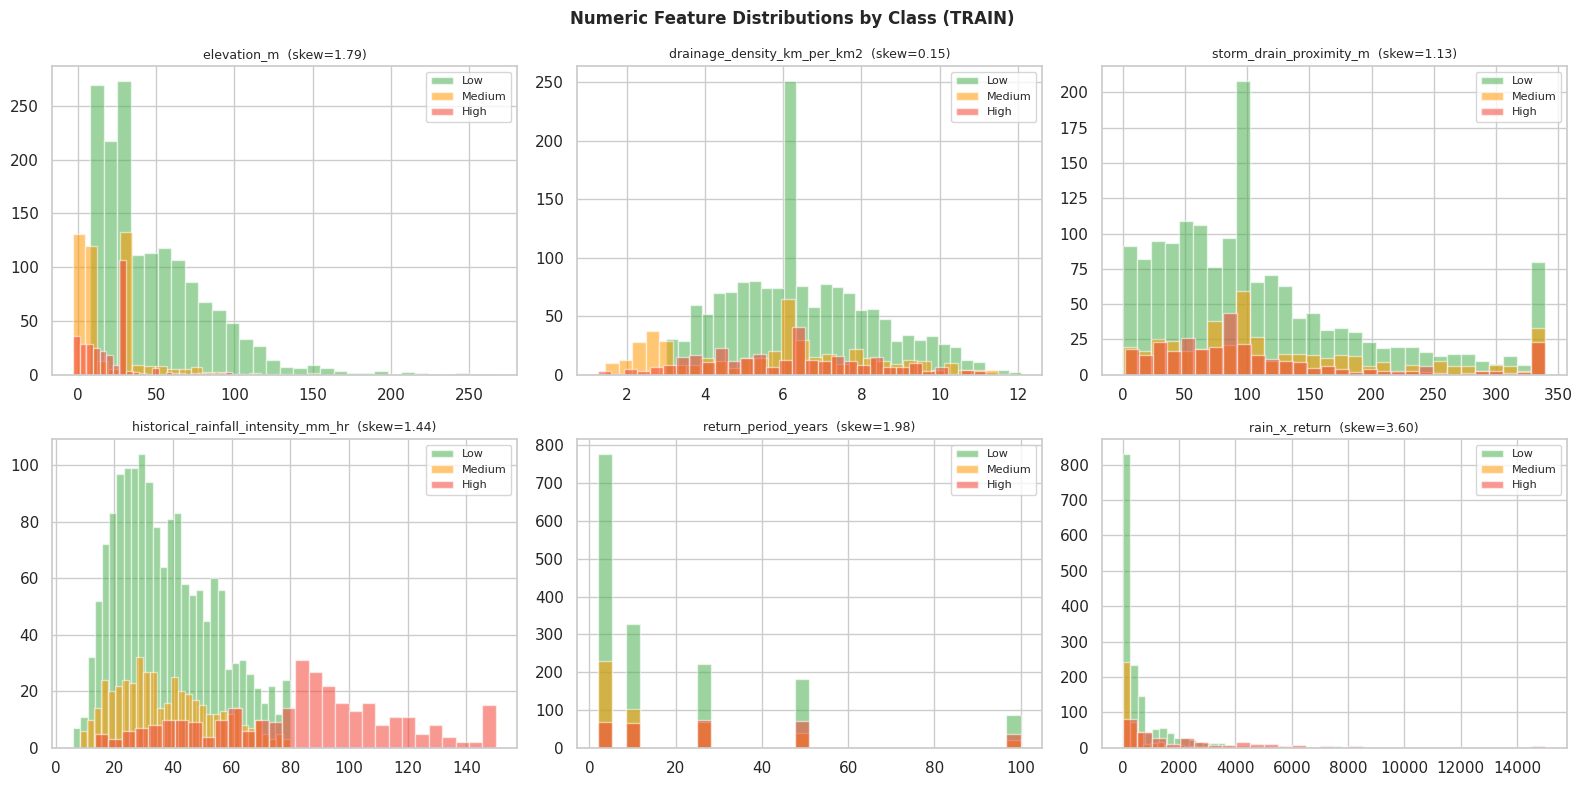

In [9]:
# ── 2.4 Phân bố numeric features theo class ────────────────────────────────────
core_num = ['elevation_m','drainage_density_km_per_km2','storm_drain_proximity_m',
            'historical_rainfall_intensity_mm_hr','return_period_years','rain_x_return']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(core_num):
    for cls in ['Low','Medium','High']:
        axes[i].hist(train_df[train_df['risk_class']==cls][feat], bins=30,
                     alpha=0.55, label=cls, color=palette[cls])
    axes[i].set_title(f'{feat}  (skew={train_df[feat].skew():.2f})', fontsize=9)
    axes[i].legend(fontsize=8)
plt.suptitle('Numeric Feature Distributions by Class (TRAIN)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

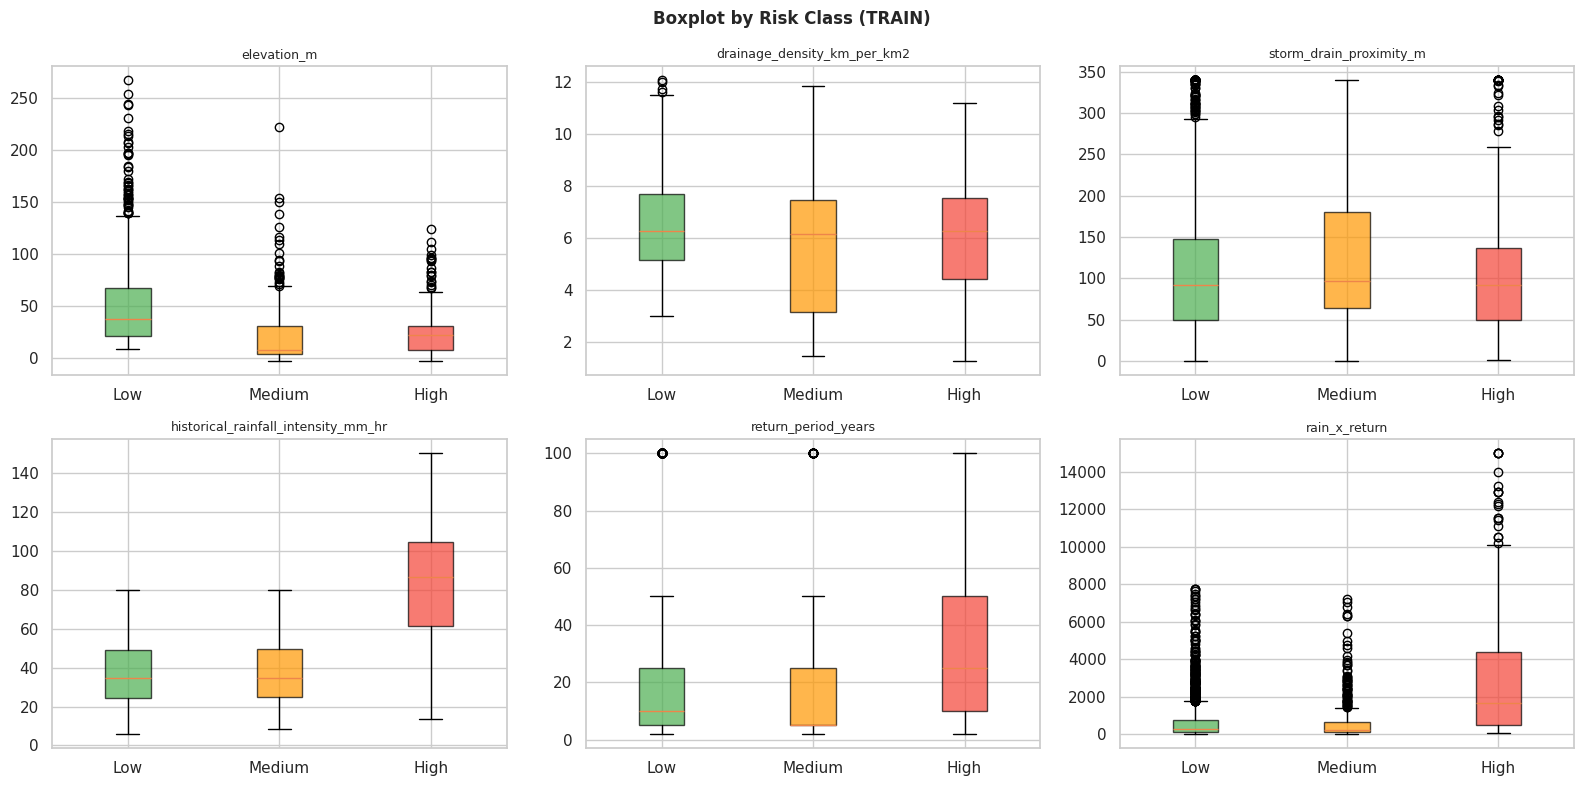

In [10]:
# ── 2.5 Boxplot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(core_num):
    data_by_cls = [train_df[train_df['risk_class']==c][feat] for c in ['Low','Medium','High']]
    bp = axes[i].boxplot(data_by_cls, labels=['Low','Medium','High'], patch_artist=True)
    for patch, c in zip(bp['boxes'], ['Low','Medium','High']):
        patch.set_facecolor(palette[c])
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=9)
plt.suptitle('Boxplot by Risk Class (TRAIN)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── 2.6 Pearson & Spearman vs target ──────────────────────────────────────────
rows = []
for feat in core_num:
    p,  _ = stats.pearsonr(train_df[feat], y_train)
    sp, _ = stats.spearmanr(train_df[feat], y_train)
    rows.append({'Feature': feat, 'Pearson': round(p,4), 'Spearman': round(sp,4)})
corr_df = pd.DataFrame(rows).set_index('Feature')
corr_df['|Spearman|'] = corr_df['Spearman'].abs()
print('Correlation with target (0=High, 1=Low, 2=Medium):')
print(corr_df.sort_values('|Spearman|', ascending=False))

Correlation with target (0=High, 1=Low, 2=Medium):
                                     Pearson  Spearman  |Spearman|
Feature                                                           
historical_rainfall_intensity_mm_hr  -0.4594   -0.3217      0.3217
rain_x_return                        -0.3191   -0.2550      0.2550
return_period_years                  -0.1545   -0.1659      0.1659
elevation_m                          -0.0774   -0.1335      0.1335
storm_drain_proximity_m               0.0660    0.0698      0.0698
drainage_density_km_per_km2          -0.0626   -0.0502      0.0502


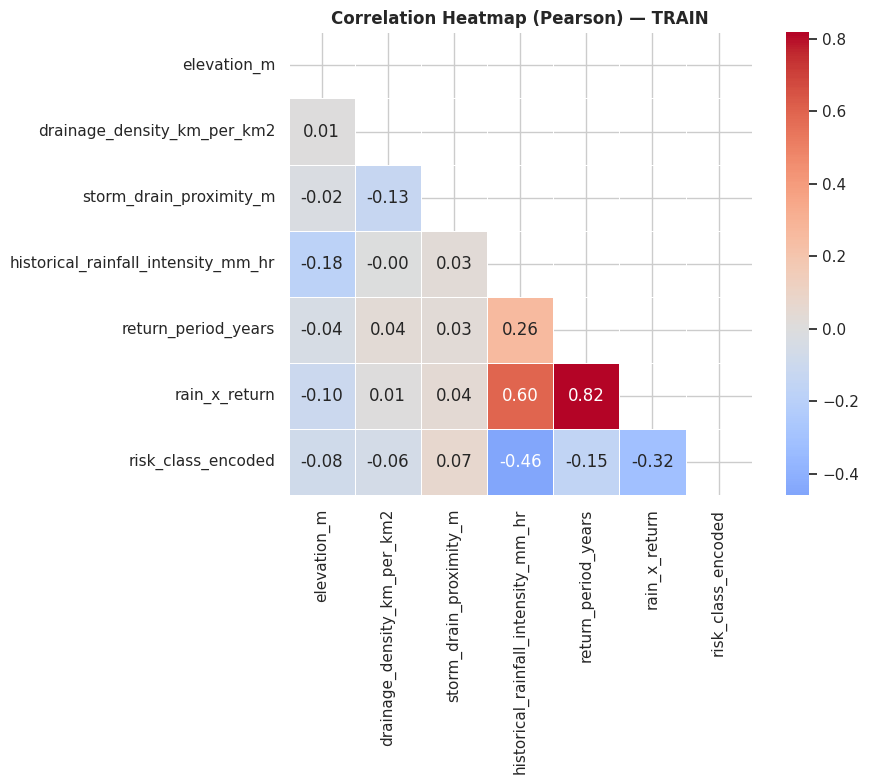

In [12]:
# ── 2.7 Correlation heatmap ────────────────────────────────────────────────────
corr_matrix = train_df[core_num + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Pearson) — TRAIN', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

% samples với elevation < 5m trong mỗi class:
risk_class        High    Low  Medium
is_very_low_elev                     
0                 80.4  100.0    69.7
1                 19.6    0.0    30.3


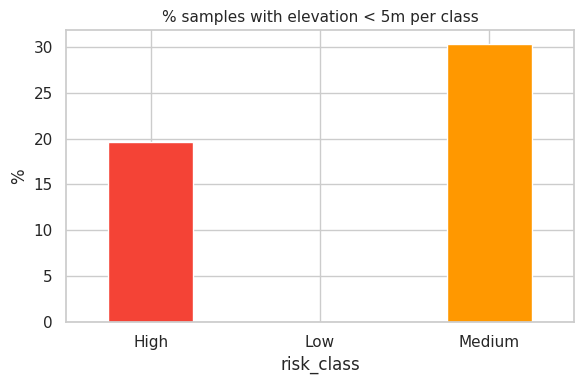

In [13]:
# ── 2.8 is_very_low_elev: signal check ────────────────────────────────────────
elev_cross = (
    pd.crosstab(train_df['is_very_low_elev'], train_df['risk_class'], normalize='columns') * 100
).round(1)
print('% samples với elevation < 5m trong mỗi class:')
print(elev_cross)

elev_cross.loc[1].plot(kind='bar', color=[palette[c] for c in elev_cross.columns],
                        figsize=(6, 4), edgecolor='white')
plt.title('% samples with elevation < 5m per class', fontsize=11)
plt.ylabel('%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rain_x_return mean per class (key: High vs Medium phân biệt nhau):
              mean  median
risk_class                
High        2977.0  1651.0
Low          748.0   257.0
Medium       672.0   240.0


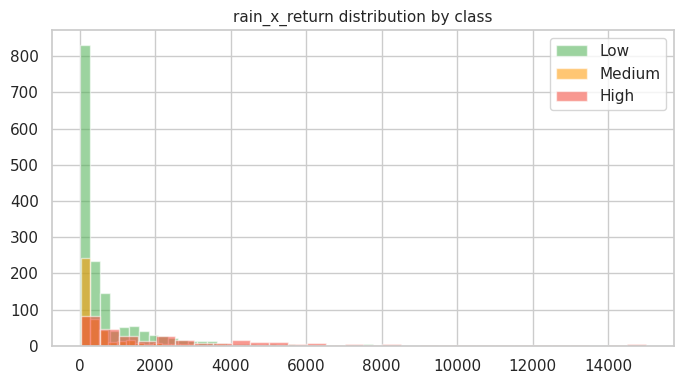

In [14]:
# ── 2.9 rain_x_return: signal check ──────────────────────────────────────────
print('rain_x_return mean per class (key: High vs Medium phân biệt nhau):')
print(train_df.groupby('risk_class')['rain_x_return'].agg(['mean','median']).round(0))

fig, ax = plt.subplots(figsize=(7, 4))
for cls in ['Low','Medium','High']:
    ax.hist(train_df[train_df['risk_class']==cls]['rain_x_return'],
            bins=30, alpha=0.55, label=cls, color=palette[cls])
ax.set_title('rain_x_return distribution by class', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# ── 2.10 Outlier summary ──────────────────────────────────────────────────────
print('Outlier detection (IQR method) — TRAIN:')
print('-'*58)
for feat in core_num:
    Q1, Q3 = train_df[feat].quantile(0.25), train_df[feat].quantile(0.75)
    n_out = ((train_df[feat] < Q1-1.5*(Q3-Q1)) | (train_df[feat] > Q3+1.5*(Q3-Q1))).sum()
    print(f'{feat:<45} {n_out:>4} outliers ({n_out/len(train_df)*100:.1f}%)')

Outlier detection (IQR method) — TRAIN:
----------------------------------------------------------
elevation_m                                     76 outliers (3.2%)
drainage_density_km_per_km2                      2 outliers (0.1%)
storm_drain_proximity_m                        167 outliers (7.0%)
historical_rainfall_intensity_mm_hr             91 outliers (3.8%)
return_period_years                            142 outliers (6.0%)
rain_x_return                                  266 outliers (11.2%)


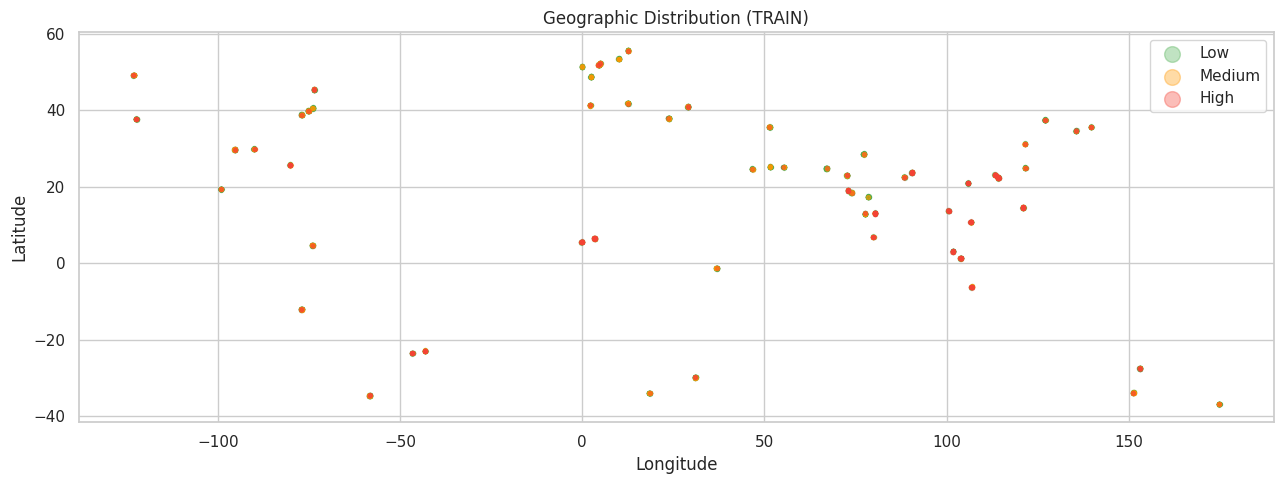

In [16]:
# ── 2.11 Geographic distribution ──────────────────────────────────────────────
plt.figure(figsize=(13, 5))
for cls in ['Low','Medium','High']:
    sub = train_df[train_df['risk_class']==cls]
    plt.scatter(sub['longitude'], sub['latitude'], alpha=0.35, s=8,
                label=cls, color=palette[cls])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution (TRAIN)', fontsize=12)
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

# 3.utils

In [17]:
results_log = []   # tổng hợp tất cả models


def _cross_validate_no_clone(estimator, X, y, cv, scoring, fit_params):
    """Manual CV for estimators that cannot be cloned by sklearn.clone."""
    result = {f'test_{name}': [] for name in scoring}
    result.update({f'train_{name}': [] for name in scoring})

    for train_idx, val_idx in cv.split(X, y):
        estimator_fold = estimator.__class__(**estimator.get_params())
        X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
        X_val_fold = X.iloc[val_idx] if hasattr(X, 'iloc') else X[val_idx]
        y_train_fold = y.iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx]
        y_val_fold = y.iloc[val_idx] if hasattr(y, 'iloc') else y[val_idx]

        if fit_params:
            estimator_fold.fit(X_train_fold, y_train_fold, **fit_params)
        else:
            estimator_fold.fit(X_train_fold, y_train_fold)

        for name, scorer in scoring.items():
            result[f'train_{name}'].append(scorer(estimator_fold, X_train_fold, y_train_fold))
            result[f'test_{name}'].append(scorer(estimator_fold, X_val_fold, y_val_fold))

    return {k: np.array(v) for k, v in result.items()}


def run_cv_and_test(model_or_pipe, X_tr, y_tr, X_te, y_te, model_name,
                    sample_weight=None, fe_tag='baseline'):
    """
    10-fold Stratified CV -> fit full train -> evaluate test.
    sample_weight: dùng khi model cần fit(sample_weight=...) thay vì class_weight param.
    fe_tag: 'baseline' | '+G3' để track feature set đang dùng.
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # CV không support sample_weight trực tiếp -> fit_params qua cross_validate
    if sample_weight is not None:
        fit_params = {'clf__sample_weight': sample_weight} \
            if hasattr(model_or_pipe, 'named_steps') \
            else {'sample_weight': sample_weight}
    else:
        fit_params = {}

    try:
        cv_res = cross_validate(
            model_or_pipe, X_tr, y_tr, cv=skf,
            scoring={
                'f2_macro': f2_macro_scorer,
                'precision_macro': precision_macro_scorer,
                'recall_macro': recall_macro_scorer,
                'f1_macro': f1_macro_scorer,
                'f1_weighted': f1_weighted_scorer,
            },
            return_train_score=True, n_jobs=-1,
            params=fit_params if fit_params else None
        )
    except RuntimeError as exc:
        if 'Cannot clone object' in str(exc) and isinstance(model_or_pipe, CatBoostClassifier):
            cv_res = _cross_validate_no_clone(
                model_or_pipe, X_tr, y_tr, skf,
                {
                    'f2_macro': f2_macro_scorer,
                    'precision_macro': precision_macro_scorer,
                    'recall_macro': recall_macro_scorer,
                    'f1_macro': f1_macro_scorer,
                    'f1_weighted': f1_weighted_scorer,
                },
                fit_params if fit_params else {}
            )
        else:
            raise

    cv_f2     = cv_res['test_f2_macro'].mean()
    cv_f2_std = cv_res['test_f2_macro'].std()
    cv_prec   = cv_res['test_precision_macro'].mean()
    cv_rec    = cv_res['test_recall_macro'].mean()
    cv_f1m    = cv_res['test_f1_macro'].mean()
    cv_f1w    = cv_res['test_f1_weighted'].mean()
    tr_f2     = cv_res['train_f2_macro'].mean()
    gap       = tr_f2 - cv_f2

    # Fit full train
    if sample_weight is not None:
        model_or_pipe.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model_or_pipe.fit(X_tr, y_tr)

    y_pred     = model_or_pipe.predict(X_te)
    test_f2    = fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0)
    test_prec  = precision_score(y_te, y_pred, average='macro', zero_division=0)
    test_rec   = recall_score(y_te, y_pred, average='macro', zero_division=0)
    test_f1m   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    test_f1w   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    beat_base  = '🎯 BEAT BASELINE' if test_f2 > BASELINE_F2 else ''

    print(f'\n{"="*65}')
    print(f'  {model_name}  [{fe_tag}]')
    print(f'{"="*65}')
    print(f'  [CV {N_SPLITS}-fold ] F2-macro : {cv_f2:.4f} ± {cv_f2_std:.4f}')
    print(f'  [CV {N_SPLITS}-fold ] Precision: {cv_prec:.4f}  | Recall: {cv_rec:.4f}  | F1-macro: {cv_f1m:.4f}')
    print(f'  [CV {N_SPLITS}-fold ] F1-wgtd  : {cv_f1w:.4f}')
    print(f'  [Train full] F2-macro : {tr_f2:.4f}   gap: {gap:.4f}{" ⚠️" if gap>0.1 else " ✅"}')
    print(f'  [TEST      ] F2-macro : {test_f2:.4f}  {beat_base}')
    print(f'  [TEST      ] Precision: {test_prec:.4f}  | Recall: {test_rec:.4f}  | F1-macro: {test_f1m:.4f}')
    print(f'  [TEST      ] F1-wgtd  : {test_f1w:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

    rec = {
        'model': model_name, 'fe_tag': fe_tag,
        'cv_f2': round(cv_f2,4), 'cv_f2_std': round(cv_f2_std,4),
        'cv_precision': round(cv_prec,4), 'cv_recall': round(cv_rec,4),
        'cv_f1_macro': round(cv_f1m,4), 'cv_f1w': round(cv_f1w,4),
        'train_f2': round(tr_f2,4), 'gap': round(gap,4),
        'test_f2': round(test_f2,4),
        'test_precision': round(test_prec,4), 'test_recall': round(test_rec,4),
        'test_f1_macro': round(test_f1m,4), 'test_f1w': round(test_f1w,4),
        'beat_baseline': test_f2 > BASELINE_F2,
    }
    results_log.append(rec)
    return model_or_pipe, rec


def plot_cm(fitted_model, X_te, y_te, model_name):
    y_pred = fitted_model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm / cm.sum(axis=1, keepdims=True)],
        ['d', '.1%'],
        ['Count', 'Row %']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        ax.set_title(f'Confusion Matrix ({title})')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.suptitle(model_name, fontweight='bold')
    plt.tight_layout()
    plt.show()


def make_smote_pipe(estimator):
    return ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ('clf',   estimator)
    ])


def optuna_cv(model, X_tr, y_tr, sample_weight=None):
    """5-fold CV F2-macro cho Optuna objective."""
    skf    = StratifiedKFold(n_splits=N_SPLITS_TUNE, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        X_fold_tr  = X_tr.iloc[tr_idx]  if hasattr(X_tr, 'iloc') else X_tr[tr_idx]
        X_fold_val = X_tr.iloc[val_idx] if hasattr(X_tr, 'iloc') else X_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]

        sw_fold = sample_weight[tr_idx] if sample_weight is not None else None

        if sw_fold is not None:
            model.fit(X_fold_tr, y_fold_tr, sample_weight=sw_fold)
        else:
            model.fit(X_fold_tr, y_fold_tr)

        y_pred = model.predict(X_fold_val)
        scores.append(fbeta_score(y_fold_val, y_pred, beta=2, average='macro', zero_division=0))

    return np.mean(scores)


print('✅ Helper functions defined')

✅ Helper functions defined


# 4.BASELINE (NO PROCESSED)

In [18]:
# 4.1 Dummy Classifier
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
run_cv_and_test(dummy, X_train, y_train, X_test, y_test, 'Dummy — Most Frequent Class')


  Dummy — Most Frequent Class  [baseline]
  [CV 10-fold ] F2-macro : 0.3038 ± 0.0003
  [CV 10-fold ] Precision: 0.2243  | Recall: 0.3333  | F1-macro: 0.2682
  [CV 10-fold ] F1-wgtd  : 0.5415
  [Train full] F2-macro : 0.3038   gap: 0.0000 ✅
  [TEST      ] F2-macro : 0.3038  
  [TEST      ] Precision: 0.2243  | Recall: 0.3333  | F1-macro: 0.2681
  [TEST      ] F1-wgtd  : 0.5413

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        79
         Low       0.67      1.00      0.80       399
      Medium       0.00      0.00      0.00       115

    accuracy                           0.67       593
   macro avg       0.22      0.33      0.27       593
weighted avg       0.45      0.67      0.54       593



(DummyClassifier(random_state=42, strategy='most_frequent'),
 {'model': 'Dummy — Most Frequent Class',
  'fe_tag': 'baseline',
  'cv_f2': np.float64(0.3038),
  'cv_f2_std': np.float64(0.0003),
  'cv_precision': np.float64(0.2243),
  'cv_recall': np.float64(0.3333),
  'cv_f1_macro': np.float64(0.2682),
  'cv_f1w': np.float64(0.5415),
  'train_f2': np.float64(0.3038),
  'gap': np.float64(0.0),
  'test_f2': 0.3038,
  'test_precision': 0.2243,
  'test_recall': 0.3333,
  'test_f1_macro': 0.2681,
  'test_f1w': 0.5413,
  'beat_baseline': False})


  RF — No Preprocessing (raw)  [baseline]
  [CV 10-fold ] F2-macro : 0.8191 ± 0.0294
  [CV 10-fold ] Precision: 0.9154  | Recall: 0.8041  | F1-macro: 0.8473
  [CV 10-fold ] F1-wgtd  : 0.8958
  [Train full] F2-macro : 1.0000   gap: 0.1809 ⚠️
  [TEST      ] F2-macro : 0.8789  
  [TEST      ] Precision: 0.9401  | Recall: 0.8676  | F1-macro: 0.8985
  [TEST      ] F1-wgtd  : 0.9336

              precision    recall  f1-score   support

        High       0.97      0.75      0.84        79
         Low       0.94      0.99      0.96       399
      Medium       0.92      0.86      0.89       115

    accuracy                           0.94       593
   macro avg       0.94      0.87      0.90       593
weighted avg       0.94      0.94      0.93       593



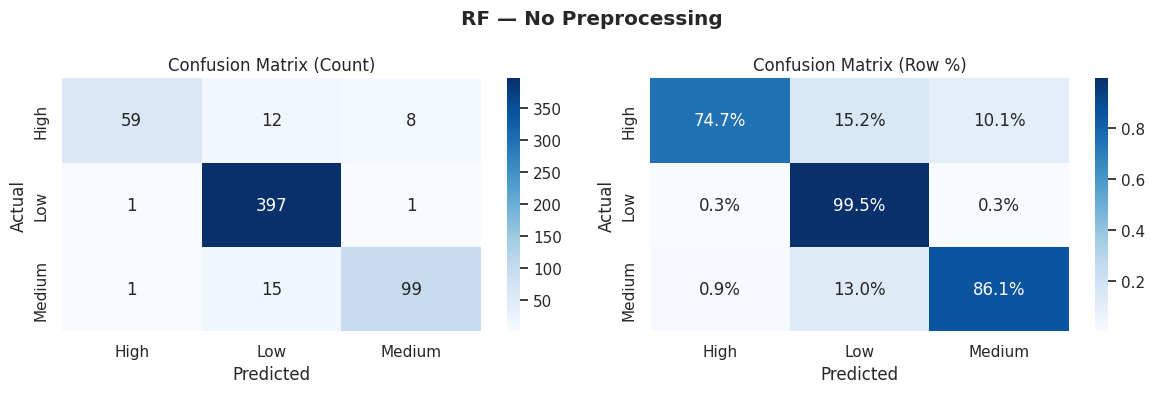

In [19]:
# 4.2 Random Forest — raw
rf_raw = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_raw_fitted, _ = run_cv_and_test(
    rf_raw, X_train, y_train, X_test, y_test,
    'RF — No Preprocessing (raw)'
)
plot_cm(rf_raw_fitted, X_test, y_test, 'RF — No Preprocessing')

In [20]:
# 4.3 XGBoost — raw
xgb_raw = XGBClassifier(
    n_estimators=200, eval_metric='mlogloss',
    verbosity=0, random_state=RANDOM_STATE, n_jobs=-1
)
xgb_raw_fitted, _ = run_cv_and_test(
    xgb_raw, X_train, y_train, X_test, y_test,
    'XGBoost — No Preprocessing (raw)'
)


  XGBoost — No Preprocessing (raw)  [baseline]
  [CV 10-fold ] F2-macro : 0.8779 ± 0.0306
  [CV 10-fold ] Precision: 0.8907  | Recall: 0.8769  | F1-macro: 0.8810
  [CV 10-fold ] F1-wgtd  : 0.9157
  [Train full] F2-macro : 1.0000   gap: 0.1221 ⚠️
  [TEST      ] F2-macro : 0.9177  
  [TEST      ] Precision: 0.9121  | Recall: 0.9192  | F1-macro: 0.9156
  [TEST      ] F1-wgtd  : 0.9361

              precision    recall  f1-score   support

        High       0.89      0.89      0.89        79
         Low       0.96      0.95      0.95       399
      Medium       0.89      0.92      0.91       115

    accuracy                           0.94       593
   macro avg       0.91      0.92      0.92       593
weighted avg       0.94      0.94      0.94       593



# 5.PREPROCESSOR

In [21]:
# Fit clip threshold trên TRAIN — KHÔNG dùng test để tính
CLIP_UPPER = X_train['storm_drain_proximity_m'].quantile(0.95)
print(f'95th percentile (train): {CLIP_UPPER:.2f} m')

X_train_pp = X_train.copy()
X_test_pp  = X_test.copy()

X_train_pp['storm_drain_proximity_m'] = X_train_pp['storm_drain_proximity_m'].clip(upper=CLIP_UPPER)
X_test_pp['storm_drain_proximity_m']  = X_test_pp['storm_drain_proximity_m'].clip(upper=CLIP_UPPER)

print(f'Max after clip — train: {X_train_pp["storm_drain_proximity_m"].max():.1f}')
print(f'Max after clip — test : {X_test_pp["storm_drain_proximity_m"].max():.1f}')
print('✅ Preprocessing done')

95th percentile (train): 339.16 m
Max after clip — train: 339.2
Max after clip — test : 339.2
✅ Preprocessing done


# 6.RANDOM FOREST

In [22]:
# RF default — class_weight='balanced' (v1: balanced > no handling cho RF)
rf_base = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_base_fitted, _ = run_cv_and_test(
    rf_base, X_train, y_train, X_test, y_test,
    'RF — Default', fe_tag='baseline'
)


  RF — Default  [baseline]
  [CV 10-fold ] F2-macro : 0.8197 ± 0.0275
  [CV 10-fold ] Precision: 0.9219  | Recall: 0.8040  | F1-macro: 0.8493
  [CV 10-fold ] F1-wgtd  : 0.8981
  [Train full] F2-macro : 1.0000   gap: 0.1803 ⚠️
  [TEST      ] F2-macro : 0.8736  
  [TEST      ] Precision: 0.9392  | Recall: 0.8620  | F1-macro: 0.8942
  [TEST      ] F1-wgtd  : 0.9316

              precision    recall  f1-score   support

        High       0.97      0.72      0.83        79
         Low       0.93      0.99      0.96       399
      Medium       0.92      0.87      0.89       115

    accuracy                           0.93       593
   macro avg       0.94      0.86      0.89       593
weighted avg       0.94      0.93      0.93       593



In [23]:
# RF Optuna tuning
def rf_objective(trial):
    p = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_categorical('max_depth', [None, 8, 15, 25]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt','log2',0.4,0.6]),
        'class_weight'     : trial.suggest_categorical('class_weight',
                                ['balanced','balanced_subsample',None]),
    }
    m = RandomForestClassifier(**p, random_state=RANDOM_STATE, n_jobs=-1)
    return optuna_cv(m, X_train, y_train)

study_rf = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(rf_objective, n_trials=60, show_progress_bar=True)
print(f'\n🏆 Best CV F2-macro (RF): {study_rf.best_value:.4f}')
print('Best params:', study_rf.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]


🏆 Best CV F2-macro (RF): 0.9138
Best params: {'n_estimators': 314, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 0.6, 'class_weight': 'balanced'}


In [24]:
# 6.3 SMOTE (ImbPipeline)
# SMOTE chỉ apply trên train fold của từng CV split → không leak vào val fold
rf_smote = make_smote_pipe(
    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
)
run_cv_and_test(rf_smote, X_train_pp, y_train, X_test_pp, y_test,
                'RF — SMOTE (ImbPipeline)')


  RF — SMOTE (ImbPipeline)  [baseline]
  [CV 10-fold ] F2-macro : 0.8260 ± 0.0276
  [CV 10-fold ] Precision: 0.8784  | Recall: 0.8168  | F1-macro: 0.8423
  [CV 10-fold ] F1-wgtd  : 0.8896
  [Train full] F2-macro : 1.0000   gap: 0.1740 ⚠️
  [TEST      ] F2-macro : 0.8962  
  [TEST      ] Precision: 0.9110  | Recall: 0.8929  | F1-macro: 0.9015
  [TEST      ] F1-wgtd  : 0.9304

              precision    recall  f1-score   support

        High       0.90      0.84      0.87        79
         Low       0.95      0.96      0.96       399
      Medium       0.88      0.88      0.88       115

    accuracy                           0.93       593
   macro avg       0.91      0.89      0.90       593
weighted avg       0.93      0.93      0.93       593



(Pipeline(steps=[('smote', SMOTE(random_state=42)),
                 ('clf',
                  RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                         random_state=42))]),
 {'model': 'RF — SMOTE (ImbPipeline)',
  'fe_tag': 'baseline',
  'cv_f2': np.float64(0.826),
  'cv_f2_std': np.float64(0.0276),
  'cv_precision': np.float64(0.8784),
  'cv_recall': np.float64(0.8168),
  'cv_f1_macro': np.float64(0.8423),
  'cv_f1w': np.float64(0.8896),
  'train_f2': np.float64(1.0),
  'gap': np.float64(0.174),
  'test_f2': 0.8962,
  'test_precision': 0.911,
  'test_recall': 0.8929,
  'test_f1_macro': 0.9015,
  'test_f1w': 0.9304,
  'beat_baseline': False})


  RF — Tuned (Optuna)  [baseline]
  [CV 10-fold ] F2-macro : 0.9110 ± 0.0177
  [CV 10-fold ] Precision: 0.8802  | Recall: 0.9220  | F1-macro: 0.8972
  [CV 10-fold ] F1-wgtd  : 0.9312
  [Train full] F2-macro : 0.9716   gap: 0.0606 ✅
  [TEST      ] F2-macro : 0.9185  
  [TEST      ] Precision: 0.8784  | Recall: 0.9317  | F1-macro: 0.9013
  [TEST      ] F1-wgtd  : 0.9314

              precision    recall  f1-score   support

        High       0.84      0.90      0.87        79
         Low       1.00      0.92      0.96       399
      Medium       0.80      0.97      0.88       115

    accuracy                           0.93       593
   macro avg       0.88      0.93      0.90       593
weighted avg       0.94      0.93      0.93       593


  RF — Tuned (Optuna)  [+G3]
  [CV 10-fold ] F2-macro : 0.9202 ± 0.0172
  [CV 10-fold ] Precision: 0.8861  | Recall: 0.9320  | F1-macro: 0.9052
  [CV 10-fold ] F1-wgtd  : 0.9346
  [Train full] F2-macro : 0.9734   gap: 0.0532 ✅
  [TEST      ] F2-

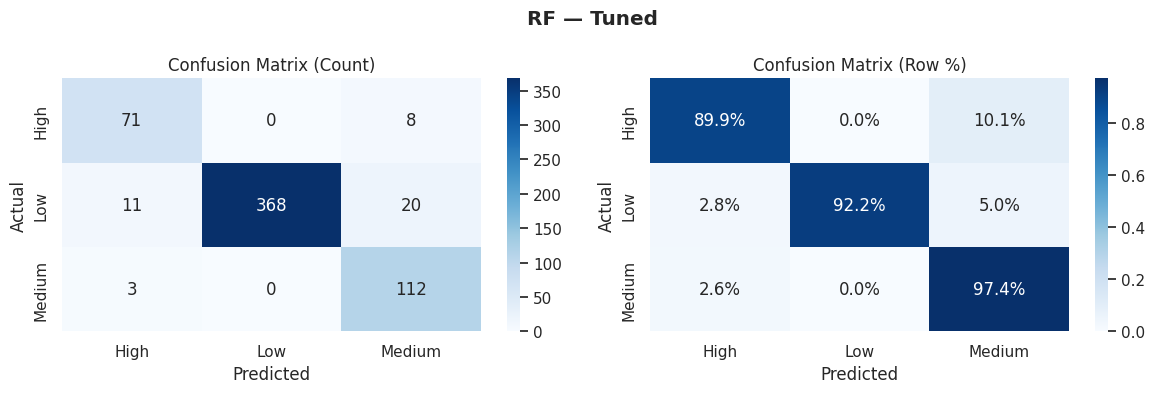

In [25]:
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1)
best_rf_fitted, _ = run_cv_and_test(
    best_rf, X_train, y_train, X_test, y_test,
    'RF — Tuned (Optuna)', fe_tag='baseline'
)

# +G3
best_rf_g3 = RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1)
run_cv_and_test(
    best_rf_g3, X_train_g3, y_train, X_test_g3, y_test,
    'RF — Tuned (Optuna)', fe_tag='+G3'
)
plot_cm(best_rf_fitted, X_test, y_test, 'RF — Tuned')

# 7.xgboost

7.1xgbclassifier

In [26]:
# Default — NO SMOTE, dùng sample_weight (v1 lesson)
xgb_default = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    eval_metric='mlogloss', verbosity=0,
    random_state=RANDOM_STATE, n_jobs=-1
)
run_cv_and_test(
    xgb_default, X_train, y_train, X_test, y_test,
    'XGB — Default (no SMOTE, sample_weight)', fe_tag='baseline',
    sample_weight=sample_weights_train
)


  XGB — Default (no SMOTE, sample_weight)  [baseline]
  [CV 10-fold ] F2-macro : 0.8945 ± 0.0267
  [CV 10-fold ] Precision: 0.8868  | Recall: 0.8979  | F1-macro: 0.8905
  [CV 10-fold ] F1-wgtd  : 0.9220
  [Train full] F2-macro : 1.0000   gap: 0.1055 ⚠️
  [TEST      ] F2-macro : 0.9350  
  [TEST      ] Precision: 0.9124  | Recall: 0.9415  | F1-macro: 0.9260
  [TEST      ] F1-wgtd  : 0.9417

              precision    recall  f1-score   support

        High       0.90      0.94      0.92        79
         Low       0.98      0.94      0.96       399
      Medium       0.86      0.95      0.90       115

    accuracy                           0.94       593
   macro avg       0.91      0.94      0.93       593
weighted avg       0.94      0.94      0.94       593



(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 {'model': 'XGB — Default (no SMOTE, sample_weight)',
  'fe_tag': 'baseline',
  'cv_f2': np.float64(0.8945),
  'cv_f2_std': np.float64(0.0267),
  'cv_precision': np.float64(0.8868),
  'cv_recall': np.float64(0.897

In [27]:
# Optuna — search space tập trung vào regularization (v1: overfit gap ~0.10)
def xgb_objective(trial):
    p = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 15),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'           : trial.suggest_float('gamma', 0.0, 8.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'eval_metric': 'mlogloss', 'verbosity': 0,
        'enable_categorical': True,
        'random_state': RANDOM_STATE, 'n_jobs': -1,
    }
    m = XGBClassifier(**p)
    return optuna_cv(m, X_train, y_train, sample_weight=sample_weights_train)

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=80, show_progress_bar=True)
print(f'\n🏆 Best CV F2-macro (XGB): {study_xgb.best_value:.4f}')

  0%|          | 0/80 [00:00<?, ?it/s]


🏆 Best CV F2-macro (XGB): 0.9224



  XGB — Tuned (Optuna, no SMOTE)  [baseline]
  [CV 10-fold ] F2-macro : 0.9210 ± 0.0217
  [CV 10-fold ] Precision: 0.8835  | Recall: 0.9335  | F1-macro: 0.9047
  [CV 10-fold ] F1-wgtd  : 0.9329
  [Train full] F2-macro : 0.9513   gap: 0.0304 ✅
  [TEST      ] F2-macro : 0.9370  
  [TEST      ] Precision: 0.8886  | Recall: 0.9524  | F1-macro: 0.9165
  [TEST      ] F1-wgtd  : 0.9359

              precision    recall  f1-score   support

        High       0.85      0.97      0.91        79
         Low       1.00      0.92      0.96       399
      Medium       0.82      0.97      0.89       115

    accuracy                           0.93       593
   macro avg       0.89      0.95      0.92       593
weighted avg       0.94      0.93      0.94       593


  XGB — Tuned (Optuna, no SMOTE)  [+G3]
  [CV 10-fold ] F2-macro : 0.9258 ± 0.0231
  [CV 10-fold ] Precision: 0.8877  | Recall: 0.9389  | F1-macro: 0.9090
  [CV 10-fold ] F1-wgtd  : 0.9354
  [Train full] F2-macro : 0.9516   gap: 0.025

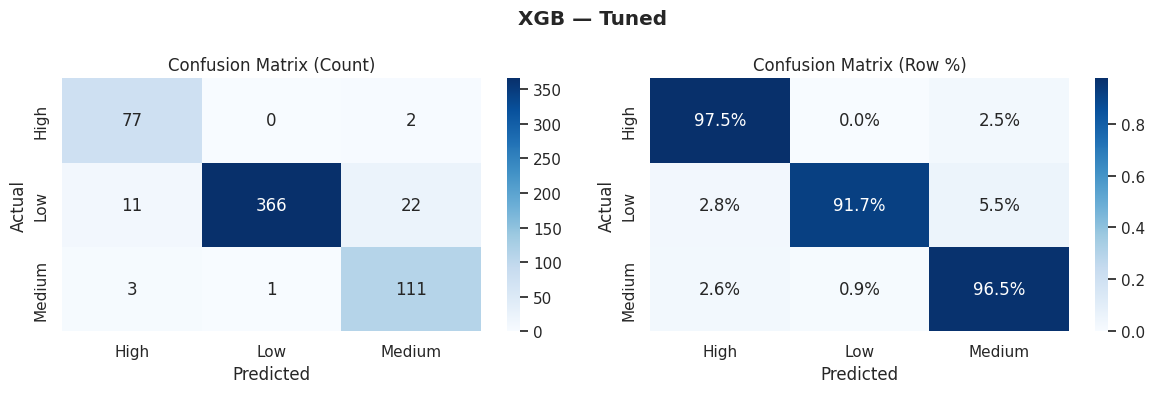

In [28]:
best_xgb = XGBClassifier(
    **{**study_xgb.best_params,
       'eval_metric': 'mlogloss', 'verbosity': 0,
       'enable_categorical': True,
       'random_state': RANDOM_STATE, 'n_jobs': -1}
)
best_xgb_fitted, _ = run_cv_and_test(
    best_xgb, X_train, y_train, X_test, y_test,
    'XGB — Tuned (Optuna, no SMOTE)', fe_tag='baseline',
    sample_weight=sample_weights_train
)

# +G3
best_xgb_g3 = XGBClassifier(
    **{**study_xgb.best_params,
       'enable_categorical': True,
       'random_state': RANDOM_STATE, 'n_jobs': -1}
)
run_cv_and_test(
    best_xgb_g3, X_train_g3, y_train, X_test_g3, y_test,
    'XGB — Tuned (Optuna, no SMOTE)', fe_tag='+G3',
    sample_weight=sample_weights_train
)

plot_cm(best_xgb_fitted, X_test, y_test, 'XGB — Tuned')

7.2 xgbrfclassifier

In [29]:
# Default
run_cv_and_test(
    XGBRFClassifier(
        n_estimators=300, max_depth=8, subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', verbosity=0, enable_categorical=True,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train, y_train, X_test, y_test,
    'XGBRF — Default', fe_tag='baseline',
    sample_weight=sample_weights_train
)


  XGBRF — Default  [baseline]
  [CV 10-fold ] F2-macro : 0.9071 ± 0.0243
  [CV 10-fold ] Precision: 0.8783  | Recall: 0.9180  | F1-macro: 0.8938
  [CV 10-fold ] F1-wgtd  : 0.9275
  [Train full] F2-macro : 0.9666   gap: 0.0595 ✅
  [TEST      ] F2-macro : 0.9202  
  [TEST      ] Precision: 0.8786  | Recall: 0.9342  | F1-macro: 0.9022
  [TEST      ] F1-wgtd  : 0.9298

              precision    recall  f1-score   support

        High       0.85      0.91      0.88        79
         Low       1.00      0.92      0.96       399
      Medium       0.79      0.97      0.87       115

    accuracy                           0.93       593
   macro avg       0.88      0.93      0.90       593
weighted avg       0.94      0.93      0.93       593



(XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                 colsample_bylevel=None, colsample_bytree=0.8, device=None,
                 early_stopping_rounds=None, enable_categorical=True,
                 eval_metric='mlogloss', feature_types=None,
                 feature_weights=None, gamma=None, grow_policy=None,
                 importance_type=None, interaction_constraints=None,
                 max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                 max_delta_step=None, max_depth=8, max_leaves=None,
                 min_child_weight=None, missing=nan, monotone_constraints=None,
                 multi_strategy=None, n_estimators=300, n_jobs=-1,
                 num_parallel_tree=None, objective='multi:softprob',
                 random_state=42, ...),
 {'model': 'XGBRF — Default',
  'fe_tag': 'baseline',
  'cv_f2': np.float64(0.9071),
  'cv_f2_std': np.float64(0.0243),
  'cv_precision': np.float64(0.8783),
  'cv_recall': np.float64(0.91

In [30]:
def xgbrf_objective(trial):
    p = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 4, 12),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'eval_metric': 'mlogloss', 'verbosity': 0,
        'enable_categorical': True,
        'random_state': RANDOM_STATE, 'n_jobs': -1,
    }
    m = XGBRFClassifier(**p)
    return optuna_cv(m, X_train, y_train, sample_weight=sample_weights_train)

study_xgbrf = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgbrf.optimize(xgbrf_objective, n_trials=60, show_progress_bar=True)
print(f'\n🏆 Best CV F2-macro (XGBRF): {study_xgbrf.best_value:.4f}')

  0%|          | 0/60 [00:00<?, ?it/s]


🏆 Best CV F2-macro (XGBRF): 0.9127


In [31]:
best_xgbrf = XGBRFClassifier(
    **{**study_xgbrf.best_params,
       'eval_metric': 'mlogloss', 'verbosity': 0,
       'enable_categorical': True,
       'random_state': RANDOM_STATE, 'n_jobs': -1}
)
best_xgbrf_fitted, _ = run_cv_and_test(
    best_xgbrf, X_train, y_train, X_test, y_test,
    'XGBRF — Tuned (Optuna)', fe_tag='baseline',
    sample_weight=sample_weights_train
)

# +G3
best_xgbrf_g3 = XGBRFClassifier(
    **{**study_xgbrf.best_params,
       'enable_categorical': True,
       'random_state': RANDOM_STATE, 'n_jobs': -1}
)
run_cv_and_test(
    best_xgbrf_g3, X_train_g3, y_train, X_test_g3, y_test,
    'XGBRF — Tuned (Optuna)', fe_tag='+G3',
    sample_weight=sample_weights_train
)


  XGBRF — Tuned (Optuna)  [baseline]
  [CV 10-fold ] F2-macro : 0.9074 ± 0.0267
  [CV 10-fold ] Precision: 0.8777  | Recall: 0.9182  | F1-macro: 0.8939
  [CV 10-fold ] F1-wgtd  : 0.9282
  [Train full] F2-macro : 0.9574   gap: 0.0501 ✅
  [TEST      ] F2-macro : 0.9211  
  [TEST      ] Precision: 0.8773  | Recall: 0.9355  | F1-macro: 0.9023
  [TEST      ] F1-wgtd  : 0.9298

              precision    recall  f1-score   support

        High       0.84      0.92      0.88        79
         Low       1.00      0.92      0.96       399
      Medium       0.79      0.97      0.87       115

    accuracy                           0.93       593
   macro avg       0.88      0.94      0.90       593
weighted avg       0.94      0.93      0.93       593


  XGBRF — Tuned (Optuna)  [+G3]
  [CV 10-fold ] F2-macro : 0.9137 ± 0.0163
  [CV 10-fold ] Precision: 0.8751  | Recall: 0.9266  | F1-macro: 0.8969
  [CV 10-fold ] F1-wgtd  : 0.9294
  [Train full] F2-macro : 0.9477   gap: 0.0341 ✅
  [TEST     

(XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                 colsample_bylevel=None, colsample_bynode=0.8018934542242249,
                 colsample_bytree=0.7803108107293302, device=None,
                 early_stopping_rounds=None, enable_categorical=True,
                 eval_metric=None, feature_types=None, feature_weights=None,
                 gamma=None, grow_policy=None, importance_type=None,
                 interaction_constraints=None, max_bin=None,
                 max_cat_threshold=None, max_cat_to_onehot=None,
                 max_delta_step=None, max_depth=12, max_leaves=None,
                 min_child_weight=8, missing=nan, monotone_constraints=None,
                 multi_strategy=None, n_estimators=430, n_jobs=-1,
                 num_parallel_tree=None, objective='multi:softprob', ...),
 {'model': 'XGBRF — Tuned (Optuna)',
  'fe_tag': '+G3',
  'cv_f2': np.float64(0.9137),
  'cv_f2_std': np.float64(0.0163),
  'cv_precision': np.float64(0.8751),
 

7.3 lightgbm

In [32]:
# # Default — n_estimators=100 cho nhanh (v1 lesson: LGBM chậm hơn XGB ở dataset nhỏ)
# run_cv_and_test(
#     LGBMClassifier(
#         n_estimators=100, learning_rate=0.05, num_leaves=31,
#         class_weight='balanced',
#         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
#     ),
#     X_train, y_train, X_test, y_test,
#     'LGBM — Default', fe_tag='baseline'
# )

7.4 histgradientboostingclassifier

In [33]:
run_cv_and_test(
    HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=63,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    X_train, y_train, X_test, y_test,
    'HGB — Default', fe_tag='baseline'
)


  HGB — Default  [baseline]
  [CV 10-fold ] F2-macro : 0.8825 ± 0.0249
  [CV 10-fold ] Precision: 0.8849  | Recall: 0.8837  | F1-macro: 0.8820
  [CV 10-fold ] F1-wgtd  : 0.9175
  [Train full] F2-macro : 1.0000   gap: 0.1175 ⚠️
  [TEST      ] F2-macro : 0.9384  
  [TEST      ] Precision: 0.9167  | Recall: 0.9447  | F1-macro: 0.9297
  [TEST      ] F1-wgtd  : 0.9467

              precision    recall  f1-score   support

        High       0.90      0.92      0.91        79
         Low       0.98      0.94      0.96       399
      Medium       0.87      0.97      0.91       115

    accuracy                           0.95       593
   macro avg       0.92      0.94      0.93       593
weighted avg       0.95      0.95      0.95       593



(HistGradientBoostingClassifier(class_weight='balanced', learning_rate=0.05,
                                max_iter=300, max_leaf_nodes=63,
                                random_state=42),
 {'model': 'HGB — Default',
  'fe_tag': 'baseline',
  'cv_f2': np.float64(0.8825),
  'cv_f2_std': np.float64(0.0249),
  'cv_precision': np.float64(0.8849),
  'cv_recall': np.float64(0.8837),
  'cv_f1_macro': np.float64(0.882),
  'cv_f1w': np.float64(0.9175),
  'train_f2': np.float64(1.0),
  'gap': np.float64(0.1175),
  'test_f2': 0.9384,
  'test_precision': 0.9167,
  'test_recall': 0.9447,
  'test_f1_macro': 0.9297,
  'test_f1w': 0.9467,
  'beat_baseline': False})

In [34]:
def hgb_objective(trial):
    p = {
        'max_iter'         : trial.suggest_int('max_iter', 100, 600),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_leaf_nodes'   : trial.suggest_int('max_leaf_nodes', 15, 200),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 5, 60),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True),
        'class_weight': 'balanced', 'random_state': RANDOM_STATE,
    }
    m = HistGradientBoostingClassifier(**p)
    return optuna_cv(m, X_train, y_train)

study_hgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_hgb.optimize(hgb_objective, n_trials=60, show_progress_bar=True)
print(f'\n🏆 Best CV F2-macro (HGB): {study_hgb.best_value:.4f}')

  0%|          | 0/60 [00:00<?, ?it/s]


🏆 Best CV F2-macro (HGB): 0.9274


In [35]:
best_hgb = HistGradientBoostingClassifier(
    **{**study_hgb.best_params, 'class_weight': 'balanced', 'random_state': RANDOM_STATE}
)
best_hgb_fitted, _ = run_cv_and_test(
    best_hgb, X_train, y_train, X_test, y_test,
    'HGB — Tuned (Optuna)', fe_tag='baseline'
)

# +G3
best_hgb_g3 = HistGradientBoostingClassifier(
    **{**study_hgb.best_params, 'class_weight': 'balanced', 'random_state': RANDOM_STATE}
)
run_cv_and_test(
    best_hgb_g3, X_train_g3, y_train, X_test_g3, y_test,
    'HGB — Tuned (Optuna)', fe_tag='+G3'
)


  HGB — Tuned (Optuna)  [baseline]
  [CV 10-fold ] F2-macro : 0.9244 ± 0.0206
  [CV 10-fold ] Precision: 0.8862  | Recall: 0.9370  | F1-macro: 0.9080
  [CV 10-fold ] F1-wgtd  : 0.9353
  [Train full] F2-macro : 0.9534   gap: 0.0290 ✅
  [TEST      ] F2-macro : 0.9345  
  [TEST      ] Precision: 0.8872  | Recall: 0.9498  | F1-macro: 0.9143
  [TEST      ] F1-wgtd  : 0.9360

              precision    recall  f1-score   support

        High       0.84      0.95      0.89        79
         Low       1.00      0.92      0.96       399
      Medium       0.82      0.98      0.89       115

    accuracy                           0.93       593
   macro avg       0.89      0.95      0.91       593
weighted avg       0.94      0.93      0.94       593


  HGB — Tuned (Optuna)  [+G3]
  [CV 10-fold ] F2-macro : 0.9267 ± 0.0222
  [CV 10-fold ] Precision: 0.8881  | Recall: 0.9396  | F1-macro: 0.9100
  [CV 10-fold ] F1-wgtd  : 0.9365
  [Train full] F2-macro : 0.9552   gap: 0.0285 ✅
  [TEST      ] F

(HistGradientBoostingClassifier(class_weight='balanced',
                                l2_regularization=3.5440453472073012,
                                learning_rate=0.014642543855336134, max_depth=3,
                                max_iter=355, max_leaf_nodes=58,
                                min_samples_leaf=38, random_state=42),
 {'model': 'HGB — Tuned (Optuna)',
  'fe_tag': '+G3',
  'cv_f2': np.float64(0.9267),
  'cv_f2_std': np.float64(0.0222),
  'cv_precision': np.float64(0.8881),
  'cv_recall': np.float64(0.9396),
  'cv_f1_macro': np.float64(0.91),
  'cv_f1w': np.float64(0.9365),
  'train_f2': np.float64(0.9552),
  'gap': np.float64(0.0285),
  'test_f2': 0.9499,
  'test_precision': 0.8976,
  'test_recall': 0.9666,
  'test_f1_macro': 0.9277,
  'test_f1w': 0.9422,
  'beat_baseline': True})

7.5CATBOOST

In [36]:
CAT_INDICES = [ALL_FEATURES.index(f) for f in CAT_FEATURES]
print(f'CAT_INDICES: {CAT_INDICES}')

CAT_INDICES: [9, 10, 11, 12, 13]


In [37]:
# ── Định nghĩa features & target ──────────────────────────────────────────────
TARGET = 'risk_class_encoded'   # 0=High, 1=Low, 2=Medium

NUM_FEATURES = [
    'elevation_m',
    'drainage_density_km_per_km2',
    'storm_drain_proximity_m',
    'historical_rainfall_intensity_mm_hr',
    'return_period_years',
    'is_very_low_elev',    # engineered: 1 nếu elevation < 5m
    'rain_x_return',       # engineered: rainfall × return_period
    'latitude',
    'longitude',
]

CAT_FEATURES = [
    'land_use',
    'soil_group',
    'storm_drain_type',
    'rainfall_source',
    'dem_source',
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

# ── Train / Test split ─────────────────────────────────────────────────────────
X_train = train_df[ALL_FEATURES].copy()   # features dùng để TRAIN
for c in CAT_FEATURES:
    X_train[c] = X_train[c].astype(str)
y_train = train_df[TARGET].copy()         # labels dùng để TRAIN

X_test  = test_df[ALL_FEATURES].copy()    # features dùng để TEST
for c in CAT_FEATURES:
    X_test[c] = X_test[c].astype(str)
y_test  = test_df[TARGET].copy()          # labels để evaluate

print('Class distribution — TRAIN (dùng để train model):')
vc_train = train_df['risk_class'].value_counts()
for cls in ['Low','Medium','High']:
    pct = vc_train[cls] / len(train_df) * 100
    print(f'  {cls:<8}: {vc_train[cls]:>5} ({pct:.1f}%)')

print('\nClass distribution — TEST (chỉ dùng để evaluate):')
vc_test = test_df['risk_class'].value_counts()
for cls in ['Low','Medium','High']:
    pct = vc_test[cls] / len(test_df) * 100


print(f'\nImbalance ratio Low/High (train): {vc_train["Low"]/vc_train["High"]:.2f}x')

Class distribution — TRAIN (dùng để train model):
  Low     :  1595 (67.3%)
  Medium  :   459 (19.4%)
  High    :   316 (13.3%)

Class distribution — TEST (chỉ dùng để evaluate):

Imbalance ratio Low/High (train): 5.05x


In [38]:
def add_g3(df):
    df = df.copy()
    # G3a: soil D (khó thấm) + mưa lớn = runoff max
    df['G3_effective_runoff'] = (
        df['historical_rainfall_intensity_mm_hr'] *
        (df['soil_group'].astype(float) + 1)
    ) / 4.0
    # G3b: soil D + vùng thấp = worst case
    df['G3_soil_elev_risk'] = (
        (df['soil_group'].astype(float) + 1) /
        (df['elevation_m'].clip(lower=0.5) + 1)
    )
    return df

train_df = add_g3(train_df)
test_df  = add_g3(test_df)

G3_FEATURES    = ['G3_effective_runoff', 'G3_soil_elev_risk']
ALL_FEAT_G3    = ALL_FEATURES + G3_FEATURES
CAT_INDICES_G3 = [ALL_FEAT_G3.index(f) for f in CAT_FEATURES]

X_train_g3 = train_df[ALL_FEAT_G3].copy()
for c in CAT_FEATURES:
    X_train_g3[c] = X_train_g3[c].astype(str)
X_test_g3  = test_df[ALL_FEAT_G3].copy()
for c in CAT_FEATURES:
    X_test_g3[c] = X_test_g3[c].astype(str)

print(f'Baseline : {len(ALL_FEATURES)} features')
print(f'+G3      : {len(ALL_FEAT_G3)} features')

print('\nG3_effective_runoff per class:')
print(train_df.groupby('risk_class')['G3_effective_runoff']
      .agg(['mean','median']).round(2))
sp, _ = stats.spearmanr(train_df['G3_effective_runoff'], y_train)
print(f'\nSpearman G3_effective_runoff vs target: {sp:.4f}')

Baseline : 14 features
+G3      : 16 features

G3_effective_runoff per class:
             mean  median
risk_class               
High        65.54   60.10
Low         26.19   21.35
Medium      24.15   18.80

Spearman G3_effective_runoff vs target: -0.3395


In [39]:
# Sample weights cho fit() — dùng khi model không có class_weight param
sample_weights_train = compute_sample_weight('balanced', y_train)

# Class weight dict cho các model hỗ trợ
unique_classes, counts = np.unique(y_train, return_counts=True)
class_weight_dict = {
    cls: len(y_train) / (len(unique_classes) * cnt)
    for cls, cnt in zip(unique_classes, counts)
}
cb_class_weights = [class_weight_dict[c] for c in sorted(unique_classes)]
# XGBoost scale_pos_weight chỉ dùng cho binary
# → với multiclass dùng sample_weight trong fit()
print('Class weight dict:', {CLASS_NAMES[k]: round(v,3) for k,v in class_weight_dict.items()})
print(f'Weight ratio High/Low: {class_weight_dict[0]/class_weight_dict[1]:.2f}x')

Class weight dict: {'High': np.float64(2.5), 'Low': np.float64(0.495), 'Medium': np.float64(1.721)}
Weight ratio High/Low: 5.05x


In [40]:
cb_default = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    cat_features=tuple(CAT_INDICES),
    eval_metric='TotalF1',
    random_seed=RANDOM_STATE,
    verbose=False
)
run_cv_and_test(
    cb_default, X_train, y_train, X_test, y_test,
    'CatBoost — Default', fe_tag='baseline',
    sample_weight=sample_weights_train
)


  CatBoost — Default  [baseline]
  [CV 10-fold ] F2-macro : 0.9220 ± 0.0155
  [CV 10-fold ] Precision: 0.8863  | Recall: 0.9336  | F1-macro: 0.9066
  [CV 10-fold ] F1-wgtd  : 0.9347
  [Train full] F2-macro : 0.9651   gap: 0.0432 ✅
  [TEST      ] F2-macro : 0.9432  
  [TEST      ] Precision: 0.8937  | Recall: 0.9588  | F1-macro: 0.9223
  [TEST      ] F1-wgtd  : 0.9389

              precision    recall  f1-score   support

        High       0.84      1.00      0.91        79
         Low       0.99      0.92      0.96       399
      Medium       0.85      0.96      0.90       115

    accuracy                           0.94       593
   macro avg       0.89      0.96      0.92       593
weighted avg       0.95      0.94      0.94       593



(CatBoostClassifier(cat_features=(9, 10, 11, 12, 13), depth=6, eval_metric='TotalF1', iterations=300, learning_rate=0.1, random_seed=42, verbose=False),
 {'model': 'CatBoost — Default',
  'fe_tag': 'baseline',
  'cv_f2': np.float64(0.922),
  'cv_f2_std': np.float64(0.0155),
  'cv_precision': np.float64(0.8863),
  'cv_recall': np.float64(0.9336),
  'cv_f1_macro': np.float64(0.9066),
  'cv_f1w': np.float64(0.9347),
  'train_f2': np.float64(0.9651),
  'gap': np.float64(0.0432),
  'test_f2': 0.9432,
  'test_precision': 0.8937,
  'test_recall': 0.9588,
  'test_f1_macro': 0.9223,
  'test_f1w': 0.9389,
  'beat_baseline': False})

In [41]:
# CatBoost Optuna — tập trung regularization để giảm overfit
def catboost_objective(trial):
    p = {
        'iterations'          : trial.suggest_int('iterations', 200, 800),
        'learning_rate'       : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth'               : trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg'         : trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
        'bagging_temperature' : trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'random_strength'     : trial.suggest_float('random_strength', 0.5, 5.0),
        'border_count'        : trial.suggest_categorical('border_count', [32, 64, 128, 254]),
        'min_data_in_leaf'    : trial.suggest_int('min_data_in_leaf', 1, 30),
    }
    m = CatBoostClassifier(
        **p,
        cat_features=CAT_INDICES,
        class_weights=cb_class_weights,
        eval_metric='TotalF1',
        random_seed=RANDOM_STATE,
        verbose=False
    )
    return optuna_cv(m, X_train, y_train)

study_cb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cb.optimize(catboost_objective, n_trials=1, show_progress_bar=True)
print(f'\n🏆 Best CV F2-macro (CatBoost): {study_cb.best_value:.4f}')
print('Best params:', study_cb.best_params)

  0%|          | 0/1 [00:00<?, ?it/s]


🏆 Best CV F2-macro (CatBoost): 0.8997
Best params: {'iterations': 425, 'learning_rate': 0.17254716573280354, 'depth': 9, 'l2_leaf_reg': 6.009974718380312, 'bagging_temperature': 0.31203728088487304, 'random_strength': 1.201975341512912, 'border_count': 64, 'min_data_in_leaf': 1}



  CatBoost — Tuned (Optuna)  [baseline]
  [CV 10-fold ] F2-macro : 0.9018 ± 0.0266
  [CV 10-fold ] Precision: 0.8770  | Recall: 0.9100  | F1-macro: 0.8911
  [CV 10-fold ] F1-wgtd  : 0.9230
  [Train full] F2-macro : 0.9816   gap: 0.0798 ✅
  [TEST      ] F2-macro : 0.9187  
  [TEST      ] Precision: 0.8752  | Recall: 0.9323  | F1-macro: 0.9005
  [TEST      ] F1-wgtd  : 0.9241

              precision    recall  f1-score   support

        High       0.82      0.94      0.88        79
         Low       0.98      0.91      0.95       399
      Medium       0.82      0.95      0.88       115

    accuracy                           0.92       593
   macro avg       0.88      0.93      0.90       593
weighted avg       0.93      0.92      0.92       593


  CatBoost — Tuned (Optuna)  [+G3]
  [CV 10-fold ] F2-macro : 0.9099 ± 0.0232
  [CV 10-fold ] Precision: 0.8832  | Recall: 0.9182  | F1-macro: 0.8987
  [CV 10-fold ] F1-wgtd  : 0.9270
  [Train full] F2-macro : 0.9867   gap: 0.0769 ✅
  [TES

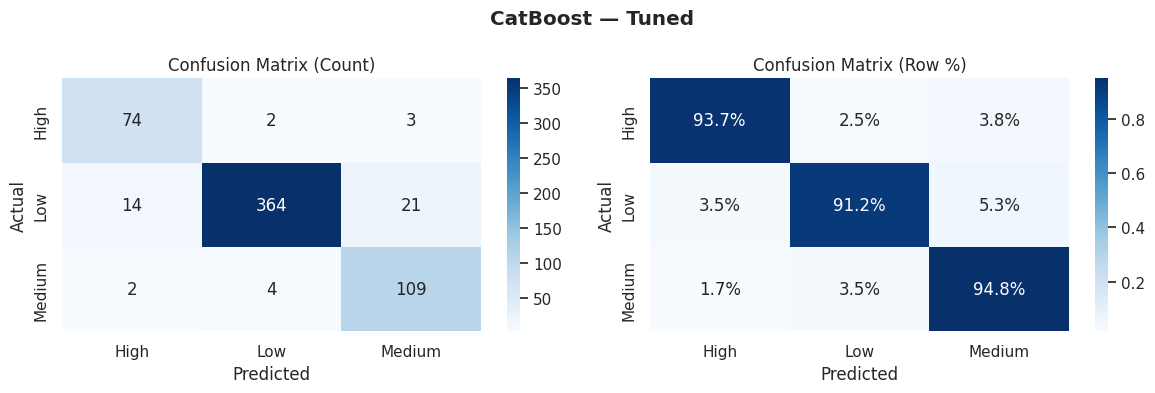

In [42]:
# Fit best CatBoost — baseline
best_cb = CatBoostClassifier(
    **study_cb.best_params,
    cat_features=CAT_INDICES,
    class_weights=cb_class_weights,
    eval_metric='TotalF1',
    random_seed=RANDOM_STATE,
    verbose=False
)
best_cb_fitted, _ = run_cv_and_test(
    best_cb, X_train, y_train, X_test, y_test,
    'CatBoost — Tuned (Optuna)', fe_tag='baseline'
)

# +G3 — CatBoost với G3 features (cat_indices vẫn giữ nguyên vì G3 là numeric)
best_cb_g3 = CatBoostClassifier(
    **study_cb.best_params,
    cat_features=CAT_INDICES_G3,
    class_weights=cb_class_weights,
    eval_metric='TotalF1',
    random_seed=RANDOM_STATE,
    verbose=False
)
run_cv_and_test(
    best_cb_g3, X_train_g3, y_train, X_test_g3, y_test,
    'CatBoost — Tuned (Optuna)', fe_tag='+G3'
)
plot_cm(best_cb_fitted, X_test, y_test, 'CatBoost — Tuned')

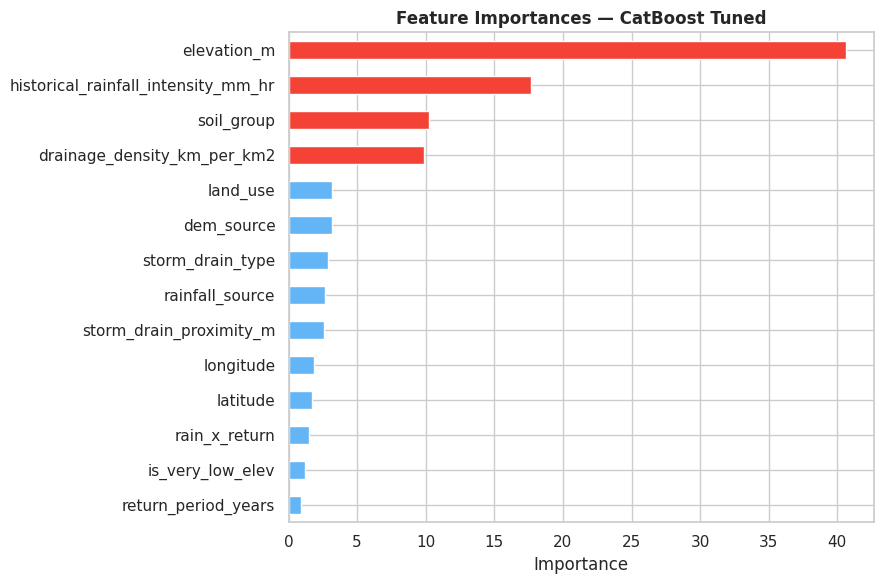

In [43]:
# CatBoost Feature Importance
cb_imp = pd.Series(
    best_cb_fitted.get_feature_importance(),
    index=ALL_FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
cb_imp.plot(kind='barh',
            color=['#F44336' if v >= cb_imp.quantile(0.75) else '#64B5F6' for v in cb_imp])
plt.title('Feature Importances — CatBoost Tuned', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 8.ANALYSIS

In [44]:
# ── Bảng kết quả ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_log)
print('📊 ALL MODELS — RESULTS SUMMARY')
print('='*100)
print(results_df.to_string(index=False))

📊 ALL MODELS — RESULTS SUMMARY
                                  model   fe_tag  cv_f2  cv_f2_std  cv_precision  cv_recall  cv_f1_macro  cv_f1w  train_f2    gap  test_f2  test_precision  test_recall  test_f1_macro  test_f1w  beat_baseline
            Dummy — Most Frequent Class baseline 0.3038     0.0003        0.2243     0.3333       0.2682  0.5415    0.3038 0.0000   0.3038          0.2243       0.3333         0.2681    0.5413          False
            RF — No Preprocessing (raw) baseline 0.8191     0.0294        0.9154     0.8041       0.8473  0.8958    1.0000 0.1809   0.8789          0.9401       0.8676         0.8985    0.9336          False
       XGBoost — No Preprocessing (raw) baseline 0.8779     0.0306        0.8907     0.8769       0.8810  0.9157    1.0000 0.1221   0.9177          0.9121       0.9192         0.9156    0.9361          False
                           RF — Default baseline 0.8197     0.0275        0.9219     0.8040       0.8493  0.8981    1.0000 0.1803   0.873

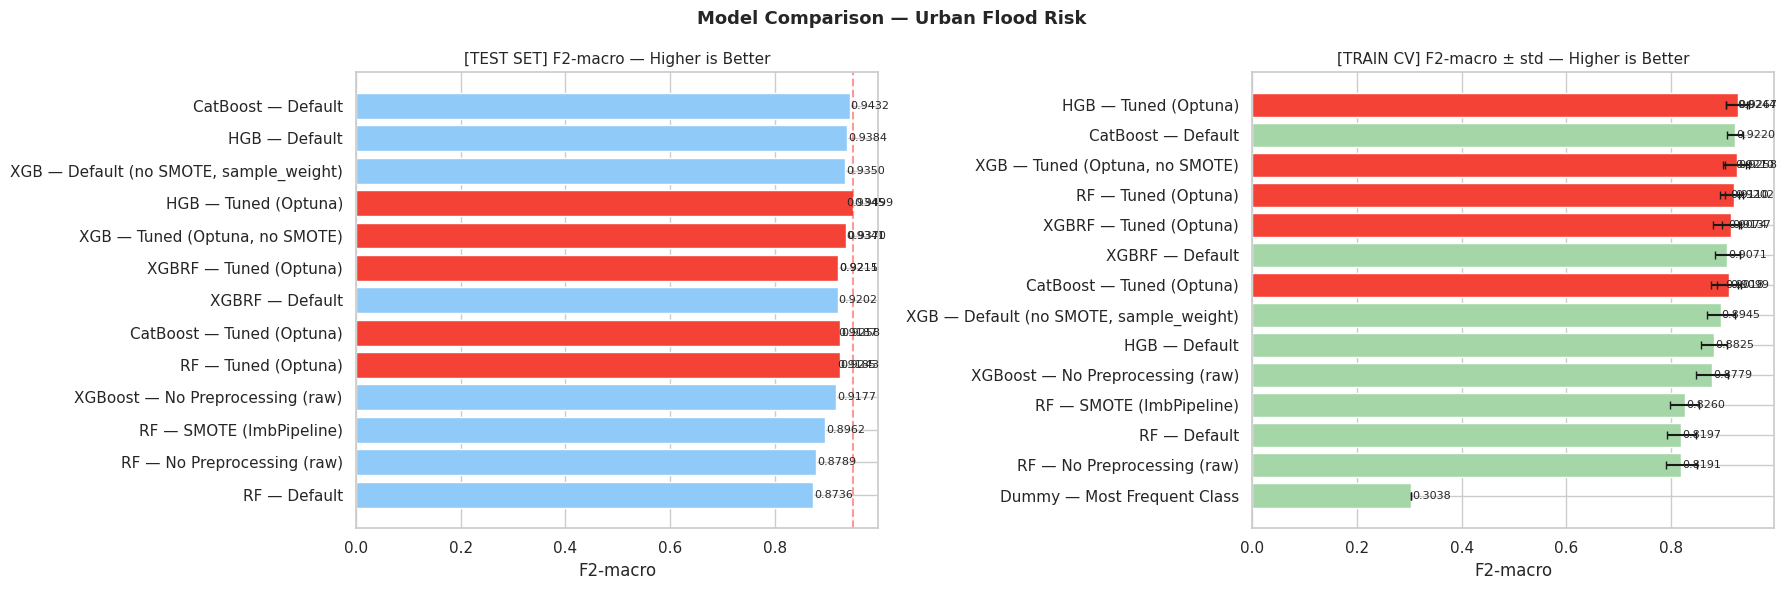

In [45]:
# ── Bar chart: Test F2-macro vs CV F2-macro ────────────────────────────────────
plot_df = results_df[~results_df['model'].str.contains('Dummy')].sort_values('test_f2', ascending=True)
bar_colors = ['#F44336' if 'Tuned' in m else '#90CAF9' for m in plot_df['model']]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Test F2-macro
bars = axes[0].barh(plot_df['model'], plot_df['test_f2'], color=bar_colors, edgecolor='white')
for bar, v in zip(bars, plot_df['test_f2']):
    axes[0].text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
axes[0].axvline(plot_df['test_f2'].max(), color='red', ls='--', alpha=0.4)
axes[0].set_title('[TEST SET] F2-macro — Higher is Better', fontsize=11)
axes[0].set_xlabel('F2-macro')

# CV F2-macro (rows có giá trị số)
cv_df = results_df[results_df['cv_f2'].apply(lambda x: isinstance(x, float))].sort_values('cv_f2', ascending=True)
bar_colors2 = ['#F44336' if 'Tuned' in m else '#A5D6A7' for m in cv_df['model']]
cv_err = cv_df['cv_f2_std'].apply(lambda x: x if isinstance(x, float) else 0)
bars2 = axes[1].barh(cv_df['model'], cv_df['cv_f2'], xerr=cv_err,
                      color=bar_colors2, edgecolor='white', capsize=3)
for bar, v in zip(bars2, cv_df['cv_f2']):
    axes[1].text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
axes[1].set_title('[TRAIN CV] F2-macro ± std — Higher is Better', fontsize=11)
axes[1].set_xlabel('F2-macro')

plt.suptitle('Model Comparison — Urban Flood Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# ── Impact: No Preprocessing vs Tuned ─────────────────────────────────────────
print('📊 Impact của Preprocessing & Tuning:')
print('-'*65)
pairs = [
    ('RF — No Preprocessing (raw)',     'RF — Tuned (RandomSearch + SMOTE)'),
    ('XGBoost — No Preprocessing (raw)','XGBClassifier — Tuned (Optuna + SMOTE)'),
]
for raw_n, tuned_n in pairs:
    r = results_df[results_df['model']==raw_n]
    t = results_df[results_df['model']==tuned_n]
    if not r.empty and not t.empty:
        rf2, tf2 = r['test_f2'].values[0], t['test_f2'].values[0]
        print(f'  {raw_n.split("—")[0].strip()}')
        print(f'    Raw   Test F2: {rf2:.4f}')
        print(f'    Tuned Test F2: {tf2:.4f}   Δ = {tf2-rf2:+.4f}')
        print()

📊 Impact của Preprocessing & Tuning:
-----------------------------------------------------------------


In [47]:
# ── Best model ────────────────────────────────────────────────────────────────
num_rows = results_df[results_df['test_f2'].apply(lambda x: isinstance(x, float))]
best     = num_rows.loc[num_rows['test_f2'].idxmax()]

print('\n🏆 BEST MODEL (Test F2-macro):')
print(f'   Model        : {best["model"]}')
print(f'   CV  F2-macro : {best["cv_f2"]}')
print(f'   Test F2-macro: {best["test_f2"]}')
print(f'   Test F1-wgtd : {best["test_f1w"]}')

# Save results for ablation studies
results_df['loss_function'] = results_df['model'].apply(lambda x: 'custom_loss' if 'custom' in x else 'default_loss')
results_df['regularization'] = results_df['model'].apply(lambda x: 'L1' if 'lasso' in x else ('L2' if 'ridge' in x else 'none'))
results_df.to_csv('model_comparison_results.csv', index=False)
print('\n✅ Saved: model_comparison_results.csv')


🏆 BEST MODEL (Test F2-macro):
   Model        : HGB — Tuned (Optuna)
   CV  F2-macro : 0.9267
   Test F2-macro: 0.9499
   Test F1-wgtd : 0.9422

✅ Saved: model_comparison_results.csv


# 10 ABLATION STUDIES

In [48]:
ablation_log = []
skf_abl = StratifiedKFold(n_splits=N_SPLITS_TUNE, shuffle=True, random_state=RANDOM_STATE)


def ablation_run(model, X_tr, y_tr, X_te, y_te,
                 model_name, dimension, variant,
                 sample_weight=None):
    """Chạy một config ablation, ghi kết quả vào ablation_log."""
    scores_cv = []
    for tr_idx, val_idx in skf_abl.split(X_tr, y_tr):
        X_fold_tr  = X_tr.iloc[tr_idx] if hasattr(X_tr,'iloc') else X_tr[tr_idx]
        X_fold_val = X_tr.iloc[val_idx] if hasattr(X_tr,'iloc') else X_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
        sw = sample_weight[tr_idx] if sample_weight is not None else None
        try:
            import sklearn
            model_clone = sklearn.base.clone(model)
        except Exception:
            from copy import deepcopy
            model_clone = deepcopy(model)
        if sw is not None:
            model_clone.fit(X_fold_tr, y_fold_tr, sample_weight=sw)
        else:
            model_clone.fit(X_fold_tr, y_fold_tr)
        y_pred_val = model_clone.predict(X_fold_val)
        scores_cv.append(
            fbeta_score(y_fold_val, y_pred_val, beta=2, average='macro', zero_division=0)
        )

    cv_f2 = np.mean(scores_cv)

    if sample_weight is not None:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    test_f2   = fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0)
    test_prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    test_rec  = recall_score(y_te, y_pred, average='macro', zero_division=0)
    test_f1m  = f1_score(y_te, y_pred, average='macro', zero_division=0)
    test_f1w  = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    rec = {
        'model': model_name, 'dimension': dimension, 'variant': variant,
        'cv_f2': round(cv_f2, 4), 'test_f2': round(test_f2, 4),
        'test_precision': round(test_prec, 4),
        'test_recall': round(test_rec, 4),
        'test_f1_macro': round(test_f1m, 4),
        'test_f1w': round(test_f1w, 4),
        'beat_baseline': test_f2 > BASELINE_F2,
    }
    ablation_log.append(rec)
    print(f'  {model_name:<22} | {variant:<35} | CV: {cv_f2:.4f} | Test F2: {test_f2:.4f}'
          f' | P: {test_prec:.4f} R: {test_rec:.4f} F1: {test_f1m:.4f}'
          f'{" 🎯" if test_f2 > BASELINE_F2 else ""}')
    return rec


print('✅ Ablation helper defined')

✅ Ablation helper defined


In [49]:
# ── Định nghĩa features & target ──────────────────────────────────────────────
TARGET = 'risk_class_encoded'   # 0=High, 1=Low, 2=Medium

NUM_FEATURES = [
    'elevation_m',
    'drainage_density_km_per_km2',
    'storm_drain_proximity_m',
    'historical_rainfall_intensity_mm_hr',
    'return_period_years',
    'is_very_low_elev',    # engineered: 1 nếu elevation < 5m
    'rain_x_return',       # engineered: rainfall × return_period
    'latitude',
    'longitude',
]

CAT_FEATURES = [
    'land_use',
    'soil_group',
    'storm_drain_type',
    'rainfall_source',
    'dem_source',
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

# ── Train / Test split ─────────────────────────────────────────────────────────
X_train = train_df[ALL_FEATURES].copy()   # features dùng để TRAIN
for c in CAT_FEATURES:
    X_train[c] = X_train[c].astype('category')
y_train = train_df[TARGET].copy()         # labels dùng để TRAIN

X_test  = test_df[ALL_FEATURES].copy()    # features dùng để TEST
for c in CAT_FEATURES:
    X_test[c] = X_test[c].astype('category')
y_test  = test_df[TARGET].copy()          # labels để evaluate


def _encode_ablation_categories(df):
    encoded = df.copy()
    for c in CAT_FEATURES:
        encoded[c] = pd.Categorical(
            encoded[c].astype('string').fillna('__missing__')
        ).codes.astype(np.int32)
    return encoded

X_train_ab = _encode_ablation_categories(X_train)
X_test_ab  = _encode_ablation_categories(X_test)

print('Class distribution — TRAIN (dùng để train model):')
vc_train = train_df['risk_class'].value_counts()
for cls in ['Low','Medium','High']:
    pct = vc_train[cls] / len(train_df) * 100
    print(f'  {cls:<8}: {vc_train[cls]:>5} ({pct:.1f}%)')

print('\nClass distribution — TEST (chỉ dùng để evaluate):')
vc_test = test_df['risk_class'].value_counts()
for cls in ['Low','Medium','High']:
    pct = vc_test[cls] / len(test_df) * 100
    print(f'  {cls:<8}: {vc_test[cls]:>5} ({pct:.1f}%)')

print(f'X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}')
print(f'X_train_ab shape: {X_train_ab.shape} | X_test_ab shape: {X_test_ab.shape}')

print(f'\nImbalance ratio Low/High (train): {vc_train["Low"]/vc_train["High"]:.2f}x')

Class distribution — TRAIN (dùng để train model):
  Low     :  1595 (67.3%)
  Medium  :   459 (19.4%)
  High    :   316 (13.3%)

Class distribution — TEST (chỉ dùng để evaluate):
  Low     :   399 (67.3%)
  Medium  :   115 (19.4%)
  High    :    79 (13.3%)
X_train shape: (2370, 14)  |  X_test shape: (593, 14)
X_train_ab shape: (2370, 14) | X_test_ab shape: (593, 14)

Imbalance ratio Low/High (train): 5.05x


In [50]:
def add_g3(df):
    df = df.copy()
    soil_numeric = df['soil_group'].astype(str).astype(float)
    df['G3_effective_runoff'] = (
        df['historical_rainfall_intensity_mm_hr'] *
        (soil_numeric + 1)
    ) / 4.0
    df['G3_soil_elev_risk'] = (
        (soil_numeric + 1) /
        (df['elevation_m'].clip(lower=0.5) + 1)
    )
    return df

train_df = add_g3(train_df)
test_df  = add_g3(test_df)

G3_FEATURES    = ['G3_effective_runoff', 'G3_soil_elev_risk']
ALL_FEAT_G3    = ALL_FEATURES + G3_FEATURES
CAT_INDICES_G3 = [ALL_FEAT_G3.index(f) for f in CAT_FEATURES]

X_train_g3 = train_df[ALL_FEAT_G3].copy()
for c in CAT_FEATURES:
    X_train_g3[c] = X_train_g3[c].astype('category')
X_test_g3  = test_df[ALL_FEAT_G3].copy()
for c in CAT_FEATURES:
    X_test_g3[c] = X_test_g3[c].astype('category')

X_train_g3_ab = _encode_ablation_categories(X_train_g3)
X_test_g3_ab  = _encode_ablation_categories(X_test_g3)

print(f'Baseline : {len(ALL_FEATURES)} features')
print(f'+G3      : {len(ALL_FEAT_G3)} features')
print(f'X_train_g3_ab shape: {X_train_g3_ab.shape} | X_test_g3_ab shape: {X_test_g3_ab.shape}')

print('\nG3_effective_runoff per class:')
print(train_df.groupby('risk_class')['G3_effective_runoff']
      .agg(['mean','median']).round(2))
sp, _ = stats.spearmanr(train_df['G3_effective_runoff'], y_train)
print(f'\nSpearman G3_effective_runoff vs target: {sp:.4f}')

Baseline : 14 features
+G3      : 16 features
X_train_g3_ab shape: (2370, 16) | X_test_g3_ab shape: (593, 16)

G3_effective_runoff per class:
             mean  median
risk_class               
High        65.54   60.10
Low         26.19   21.35
Medium      24.15   18.80

Spearman G3_effective_runoff vs target: -0.3395


In [51]:
# # ── Ablation 1: Imbalance Handling — 3 strategies × 6 models ──────────────────
# print('\n[ABLATION 1] Imbalance Handling Strategy')
# print('='*90)

# # Models dùng default params để isolate effect của imbalance strategy
# base_params_xgb  = dict(n_estimators=300, learning_rate=0.1, max_depth=6,
#                          eval_metric='mlogloss', verbosity=0,
#                          random_state=RANDOM_STATE, n_jobs=-1)
# base_params_lgbm = dict(n_estimators=100, learning_rate=0.05, num_leaves=31,
#                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
# base_params_hgb  = dict(max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE)
# base_params_rf   = dict(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
# base_params_xgbrf= dict(n_estimators=300, max_depth=8, eval_metric='mlogloss',
#                          verbosity=0, random_state=RANDOM_STATE, n_jobs=-1)
# base_params_cb   = dict(iterations=300, learning_rate=0.1, depth=6,
#                          cat_features=CAT_INDICES, eval_metric='TotalF1',
#                          random_seed=RANDOM_STATE, verbose=False)

# imbalance_configs = [
#     # (model_name, model_no_weight, model_class_weight, use_sample_weight_for_no_weight)
#     ('RF',
#      RandomForestClassifier(**base_params_rf),
#      RandomForestClassifier(**base_params_rf, class_weight='balanced'),
#      make_smote_pipe(RandomForestClassifier(**base_params_rf)),
#      None, None),

#     ('XGB',
#      XGBClassifier(**base_params_xgb),
#      XGBClassifier(**base_params_xgb),
#      make_smote_pipe(XGBClassifier(**base_params_xgb)),
#      None, sample_weights_train),

#     ('XGBRF',
#      XGBRFClassifier(**base_params_xgbrf),
#      XGBRFClassifier(**base_params_xgbrf),
#      make_smote_pipe(XGBRFClassifier(**base_params_xgbrf)),
#      None, sample_weights_train),

#     ('LGBM',
#      LGBMClassifier(**base_params_lgbm),
#      LGBMClassifier(**base_params_lgbm, class_weight='balanced'),
#      make_smote_pipe(LGBMClassifier(**base_params_lgbm)),
#      None, None),

#     ('HGB',
#      HistGradientBoostingClassifier(**base_params_hgb),
#      HistGradientBoostingClassifier(**base_params_hgb, class_weight='balanced'),
#      make_smote_pipe(HistGradientBoostingClassifier(**base_params_hgb)),
#      None, None),

#     ('CatBoost',
#      CatBoostClassifier(**base_params_cb),
#      CatBoostClassifier(**base_params_cb, class_weights=cb_class_weights),
#      make_smote_pipe(CatBoostClassifier(**base_params_cb)),
#      None, None),
# ]

# for (mname, m_none, m_weight, m_smote, _, sw) in imbalance_configs:
#     print(f'\n  --- {mname} ---')
#     ablation_run(m_none,   X_train_ab, y_train, X_test_ab, y_test,
#                  mname, 'Imbalance Handling', 'No handling',
#                  sample_weight=None)
#     ablation_run(m_weight, X_train_ab, y_train, X_test_ab, y_test,
#                  mname, 'Imbalance Handling', 'class_weight=balanced',
#                  sample_weight=sw)
#     ablation_run(m_smote,  X_train_ab, y_train, X_test_ab, y_test,
#                  mname, 'Imbalance Handling', 'SMOTE (ImbPipeline)',
#                  sample_weight=None)

In [52]:
import sklearn.base

# ── Base params (dùng chung cho Ablation 2 & 3) ────────────────────────────────
# Định nghĩa lại ở đây vì Ablation 1 bị comment out
base_params_xgb   = dict(n_estimators=300, learning_rate=0.1, max_depth=6,
                          eval_metric='mlogloss', verbosity=0,
                          random_state=RANDOM_STATE, n_jobs=-1)
base_params_lgbm  = dict(n_estimators=100, learning_rate=0.05, num_leaves=31,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
base_params_hgb   = dict(max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE)
base_params_rf    = dict(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
base_params_xgbrf = dict(n_estimators=300, max_depth=8, eval_metric='mlogloss',
                          verbosity=0, random_state=RANDOM_STATE, n_jobs=-1)
# CatBoost: KHÔNG dùng cat_features vì X_train_ab đã encode thành int
base_params_cb    = dict(iterations=300, learning_rate=0.1, depth=6,
                          eval_metric='TotalF1',
                          random_seed=RANDOM_STATE, verbose=False)

sample_weights_train = compute_sample_weight('balanced', y_train)
unique_classes, counts_cls = np.unique(y_train, return_counts=True)
class_weight_dict = {
    cls: len(y_train) / (len(unique_classes) * cnt)
    for cls, cnt in zip(unique_classes, counts_cls)
}
cb_class_weights = [class_weight_dict[c] for c in sorted(unique_classes)]

print('\n[ABLATION 2] Feature Engineering — Baseline vs +G3')
print('='*90)

fe_model_configs = [
    ('RF',       RandomForestClassifier(**base_params_rf, class_weight='balanced'),      None, None),
    ('XGB',      XGBClassifier(**base_params_xgb),                                       None, sample_weights_train),
    ('XGBRF',    XGBRFClassifier(**base_params_xgbrf),                                   None, sample_weights_train),
    ('LGBM',     LGBMClassifier(**base_params_lgbm, class_weight='balanced'),            None, None),
    ('HGB',      HistGradientBoostingClassifier(**base_params_hgb, class_weight='balanced'), None, None),
    ('CatBoost', CatBoostClassifier(**base_params_cb, class_weights=cb_class_weights),   None, None),
]

for mname, model, _, sw in fe_model_configs:
    print(f'\n  --- {mname} ---')
    # Baseline
    if isinstance(model, CatBoostClassifier):
        m_base = model.__class__(**model.get_params())
    else:
        m_base = sklearn.base.clone(model)
    ablation_run(m_base, X_train_ab, y_train, X_test_ab, y_test,
                 mname, 'Feature Engineering', 'Baseline (14 features)',
                 sample_weight=sw)
    # +G3
    if isinstance(model, CatBoostClassifier):
        m_g3 = model.__class__(**model.get_params())
    else:
        m_g3 = sklearn.base.clone(model)
    ablation_run(m_g3, X_train_g3_ab, y_train, X_test_g3_ab, y_test,
                 mname, 'Feature Engineering', '+G3 (16 features)',
                 sample_weight=sw)


[ABLATION 2] Feature Engineering — Baseline vs +G3

  --- RF ---
  RF                     | Baseline (14 features)              | CV: 0.8190 | Test F2: 0.8776 | P: 0.9401 R: 0.8662 F1: 0.8974
  RF                     | +G3 (16 features)                   | CV: 0.8466 | Test F2: 0.9128 | P: 0.9141 R: 0.9128 F1: 0.9131

  --- XGB ---
  XGB                    | Baseline (14 features)              | CV: 0.8930 | Test F2: 0.9350 | P: 0.9124 R: 0.9415 F1: 0.9260
  XGB                    | +G3 (16 features)                   | CV: 0.9024 | Test F2: 0.9486 | P: 0.9210 R: 0.9565 F1: 0.9376 🎯

  --- XGBRF ---
  XGBRF                  | Baseline (14 features)              | CV: 0.9035 | Test F2: 0.9269 | P: 0.8834 R: 0.9413 F1: 0.9082
  XGBRF                  | +G3 (16 features)                   | CV: 0.9111 | Test F2: 0.9393 | P: 0.8907 R: 0.9548 F1: 0.9188

  --- LGBM ---
  LGBM                   | Baseline (14 features)              | CV: 0.9095 | Test F2: 0.9489 | P: 0.9077 R: 0.9615 F1: 0.

In [53]:
# Tạo clipped version để so sánh
CLIP_UPPER = X_train['storm_drain_proximity_m'].quantile(0.95)
X_train_clipped = X_train.copy()
X_test_clipped  = X_test.copy()
X_train_clipped['storm_drain_proximity_m'] = X_train_clipped['storm_drain_proximity_m'].clip(upper=CLIP_UPPER)
X_test_clipped['storm_drain_proximity_m']  = X_test_clipped['storm_drain_proximity_m'].clip(upper=CLIP_UPPER)
X_train_clipped_ab = _encode_ablation_categories(X_train_clipped)
X_test_clipped_ab  = _encode_ablation_categories(X_test_clipped)

print(f'Clip threshold (95th pct train): {CLIP_UPPER:.2f}')

print('\n[ABLATION 3] Preprocessing — Raw vs Clipped')
print('='*90)

for mname, model, _, sw in fe_model_configs:
    print(f'\n  --- {mname} ---')
    if isinstance(model, CatBoostClassifier):
        m_raw  = model.__class__(**model.get_params())
        m_clip = model.__class__(**model.get_params())
    else:
        m_raw  = sklearn.base.clone(model)
        m_clip = sklearn.base.clone(model)
    ablation_run(m_raw, X_train_ab, y_train, X_test_ab, y_test,
                 mname, 'Preprocessing', 'Raw (no clip)',
                 sample_weight=sw)
    ablation_run(m_clip, X_train_clipped_ab, y_train, X_test_clipped_ab, y_test,
                 mname, 'Preprocessing', 'Clipped 95th pct',
                 sample_weight=sw)

Clip threshold (95th pct train): 339.16

[ABLATION 3] Preprocessing — Raw vs Clipped

  --- RF ---
  RF                     | Raw (no clip)                       | CV: 0.8190 | Test F2: 0.8776 | P: 0.9401 R: 0.8662 F1: 0.8974
  RF                     | Clipped 95th pct                    | CV: 0.8190 | Test F2: 0.8776 | P: 0.9401 R: 0.8662 F1: 0.8974

  --- XGB ---
  XGB                    | Raw (no clip)                       | CV: 0.8930 | Test F2: 0.9350 | P: 0.9124 R: 0.9415 F1: 0.9260
  XGB                    | Clipped 95th pct                    | CV: 0.8930 | Test F2: 0.9350 | P: 0.9124 R: 0.9415 F1: 0.9260

  --- XGBRF ---
  XGBRF                  | Raw (no clip)                       | CV: 0.9035 | Test F2: 0.9269 | P: 0.8834 R: 0.9413 F1: 0.9082
  XGBRF                  | Clipped 95th pct                    | CV: 0.9035 | Test F2: 0.9269 | P: 0.8834 R: 0.9413 F1: 0.9082

  --- LGBM ---
  LGBM                   | Raw (no clip)                       | CV: 0.9095 | Test F2: 0.94

In [54]:
ablation_df = pd.DataFrame(ablation_log)

print('📊 ABLATION FULL RESULTS')
print('='*110)
print(ablation_df.to_string(index=False))

📊 ABLATION FULL RESULTS
   model           dimension                variant  cv_f2  test_f2  test_precision  test_recall  test_f1_macro  test_f1w  beat_baseline
      RF Feature Engineering Baseline (14 features) 0.8190   0.8776          0.9401       0.8662         0.8974    0.9335          False
      RF Feature Engineering      +G3 (16 features) 0.8466   0.9128          0.9141       0.9128         0.9131    0.9393          False
     XGB Feature Engineering Baseline (14 features) 0.8930   0.9350          0.9124       0.9415         0.9260    0.9417          False
     XGB Feature Engineering      +G3 (16 features) 0.9024   0.9486          0.9210       0.9565         0.9376    0.9500           True
   XGBRF Feature Engineering Baseline (14 features) 0.9035   0.9269          0.8834       0.9413         0.9082    0.9329          False
   XGBRF Feature Engineering      +G3 (16 features) 0.9111   0.9393          0.8907       0.9548         0.9188    0.9392          False
    LGBM Feature 

In [55]:
# ── Insights per dimension ─────────────────────────────────────────────────────
print('\n📈 INSIGHTS PER ABLATION DIMENSION')
print('='*110)

for dim in ablation_df['dimension'].unique():
    sub = ablation_df[ablation_df['dimension'] == dim]
    print(f'\n{dim.upper()}')
    print('-'*110)

    # Best variant per model
    pivot = sub.pivot_table(values='test_f2', index='model', columns='variant', aggfunc='mean')
    print(pivot.round(4).to_string())

    # Winner per model
    print('\n  Winner per model:')
    for model_name in sub['model'].unique():
        m_sub = sub[sub['model'] == model_name]
        best_v = m_sub.loc[m_sub['test_f2'].idxmax(), 'variant']
        best_f2 = m_sub['test_f2'].max()
        print(f'    {model_name:<12} → {best_v:<35} | Test F2: {best_f2:.4f}')


📈 INSIGHTS PER ABLATION DIMENSION

FEATURE ENGINEERING
--------------------------------------------------------------------------------------------------------------
variant   +G3 (16 features)  Baseline (14 features)
model                                              
CatBoost             0.9456                  0.9328
HGB                  0.9389                  0.9440
LGBM                 0.9458                  0.9489
RF                   0.9128                  0.8776
XGB                  0.9486                  0.9350
XGBRF                0.9393                  0.9269

  Winner per model:
    RF           → +G3 (16 features)                   | Test F2: 0.9128
    XGB          → +G3 (16 features)                   | Test F2: 0.9486
    XGBRF        → +G3 (16 features)                   | Test F2: 0.9393
    LGBM         → Baseline (14 features)              | Test F2: 0.9489
    HGB          → Baseline (14 features)              | Test F2: 0.9440
    CatBoost     → +G3 (16 feat

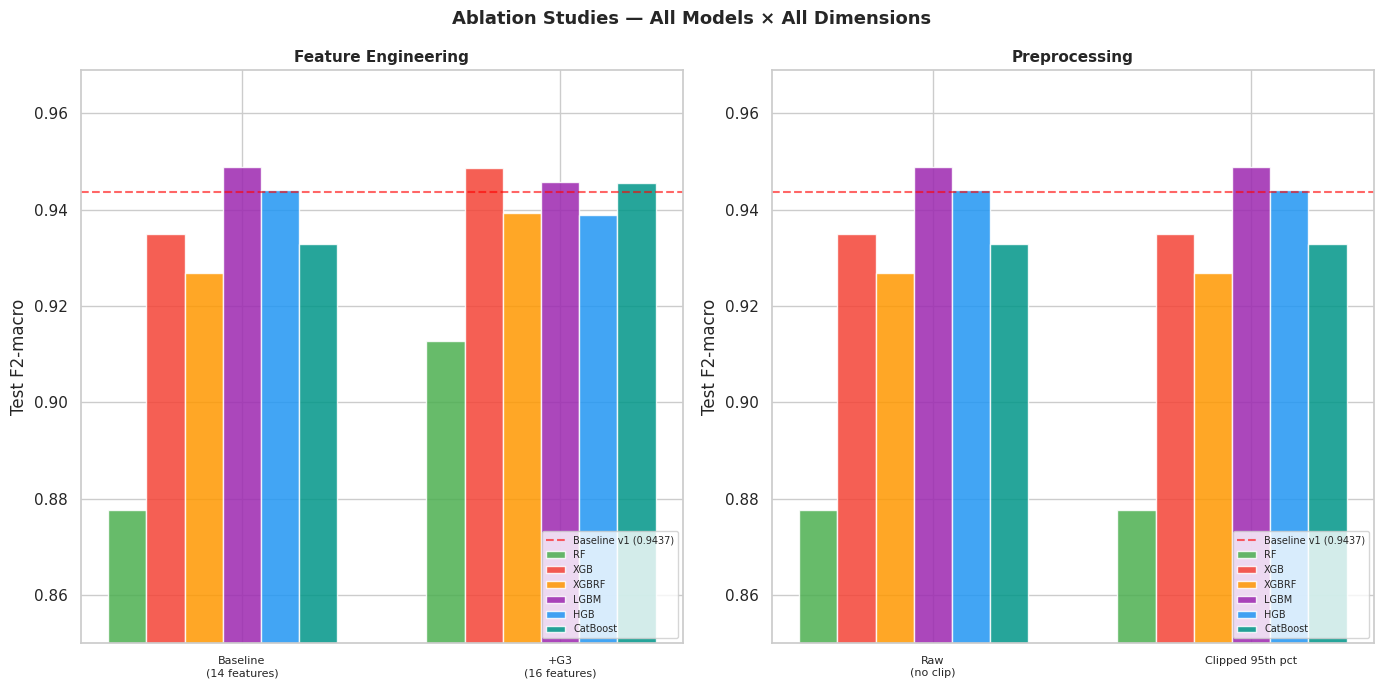

In [56]:
# ── Visualize ablation ─────────────────────────────────────────────────────────
dims = ablation_df['dimension'].unique()
fig, axes = plt.subplots(1, len(dims), figsize=(7 * len(dims), 7))
if len(dims) == 1:
    axes = [axes]

model_colors = {
    'RF': '#4CAF50', 'XGB': '#F44336', 'XGBRF': '#FF9800',
    'LGBM': '#9C27B0', 'HGB': '#2196F3', 'CatBoost': '#009688'
}

for ax, dim in zip(axes, dims):
    sub = ablation_df[ablation_df['dimension'] == dim]
    variants = sub['variant'].unique()
    models   = sub['model'].unique()
    x = np.arange(len(variants))
    width = 0.12

    for i, model in enumerate(models):
        m_sub = sub[sub['model'] == model]
        vals = [m_sub[m_sub['variant'] == v]['test_f2'].values[0]
                if len(m_sub[m_sub['variant'] == v]) > 0 else np.nan
                for v in variants]
        offset = (i - len(models)/2) * width
        ax.bar(x + offset, vals, width, label=model,
               color=model_colors.get(model, '#999'), alpha=0.85, edgecolor='white')

    ax.axhline(BASELINE_F2, color='red', ls='--', lw=1.5, alpha=0.6,
               label=f'Baseline v1 ({BASELINE_F2})')
    ax.set_xticks(x)
    ax.set_xticklabels([v.replace(' (', '\n(') for v in variants], fontsize=8)
    ax.set_title(dim, fontsize=11, fontweight='bold')
    ax.set_ylabel('Test F2-macro')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_ylim(0.85, max(ablation_df['test_f2'].max() + 0.02, BASELINE_F2 + 0.02))

plt.suptitle('Ablation Studies — All Models × All Dimensions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
results_df = pd.DataFrame(results_log)

print('📊 ALL TUNED MODELS — RESULTS SUMMARY')
print('='*140)
print(results_df[[
    'model','fe_tag','cv_f2','cv_f2_std','cv_precision','cv_recall','cv_f1_macro',
    'train_f2','gap','test_f2','test_precision','test_recall','test_f1_macro','test_f1w','beat_baseline'
]].to_string(index=False))

📊 ALL TUNED MODELS — RESULTS SUMMARY
                                  model   fe_tag  cv_f2  cv_f2_std  cv_precision  cv_recall  cv_f1_macro  train_f2    gap  test_f2  test_precision  test_recall  test_f1_macro  test_f1w  beat_baseline
            Dummy — Most Frequent Class baseline 0.3038     0.0003        0.2243     0.3333       0.2682    0.3038 0.0000   0.3038          0.2243       0.3333         0.2681    0.5413          False
            RF — No Preprocessing (raw) baseline 0.8191     0.0294        0.9154     0.8041       0.8473    1.0000 0.1809   0.8789          0.9401       0.8676         0.8985    0.9336          False
       XGBoost — No Preprocessing (raw) baseline 0.8779     0.0306        0.8907     0.8769       0.8810    1.0000 0.1221   0.9177          0.9121       0.9192         0.9156    0.9361          False
                           RF — Default baseline 0.8197     0.0275        0.9219     0.8040       0.8493    1.0000 0.1803   0.8736          0.9392       0.8620    

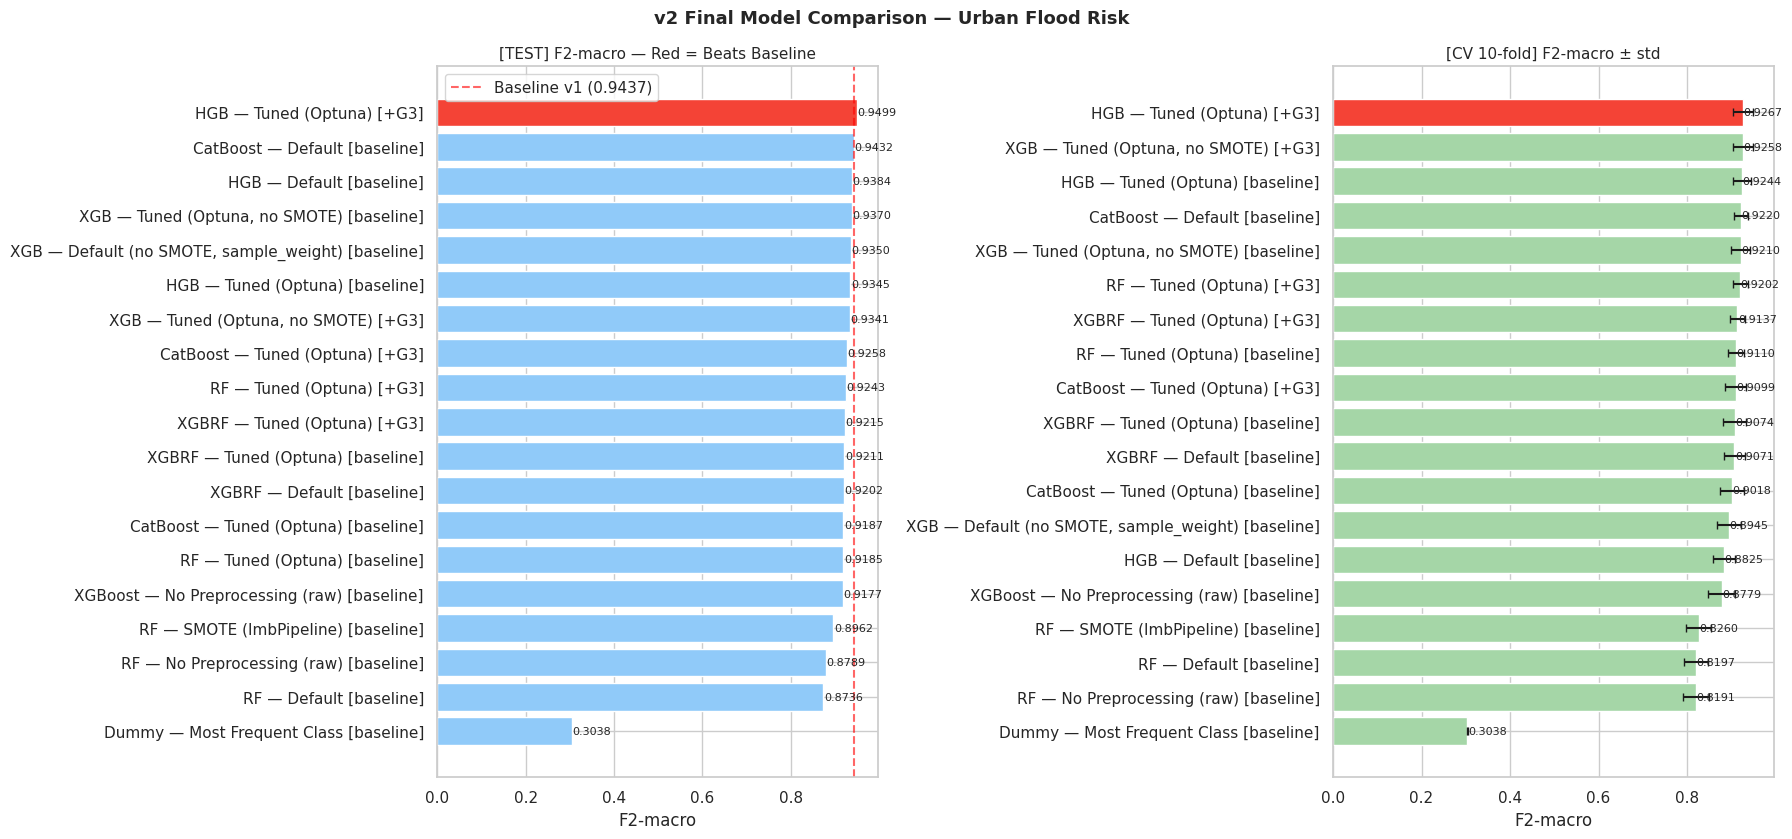

In [58]:
# ── Bar chart final ────────────────────────────────────────────────────────────
plot_df = results_df.sort_values('test_f2', ascending=True).copy()
plot_df['label'] = plot_df['model'] + ' [' + plot_df['fe_tag'] + ']'

bar_colors = ['#F44336' if b else '#90CAF9' for b in plot_df['beat_baseline']]

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(plot_df) * 0.45)))

# Test F2
bars = axes[0].barh(plot_df['label'], plot_df['test_f2'],
                     color=bar_colors, edgecolor='white')
for bar, v in zip(bars, plot_df['test_f2']):
    axes[0].text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
axes[0].axvline(BASELINE_F2, color='red', ls='--', lw=1.5, alpha=0.6,
                label=f'Baseline v1 ({BASELINE_F2})')
axes[0].set_title('[TEST] F2-macro — Red = Beats Baseline', fontsize=11)
axes[0].set_xlabel('F2-macro')
axes[0].legend()

# CV F2
plot_df_cv = results_df.sort_values('cv_f2', ascending=True).copy()
plot_df_cv['label'] = plot_df_cv['model'] + ' [' + plot_df_cv['fe_tag'] + ']'
bar_colors_cv = ['#F44336' if b else '#A5D6A7' for b in plot_df_cv['beat_baseline']]
bars2 = axes[1].barh(plot_df_cv['label'], plot_df_cv['cv_f2'],
                      xerr=plot_df_cv['cv_f2_std'],
                      color=bar_colors_cv, edgecolor='white', capsize=3)
for bar, v in zip(bars2, plot_df_cv['cv_f2']):
    axes[1].text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
axes[1].set_title('[CV 10-fold] F2-macro ± std', fontsize=11)
axes[1].set_xlabel('F2-macro')

plt.suptitle('v2 Final Model Comparison — Urban Flood Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

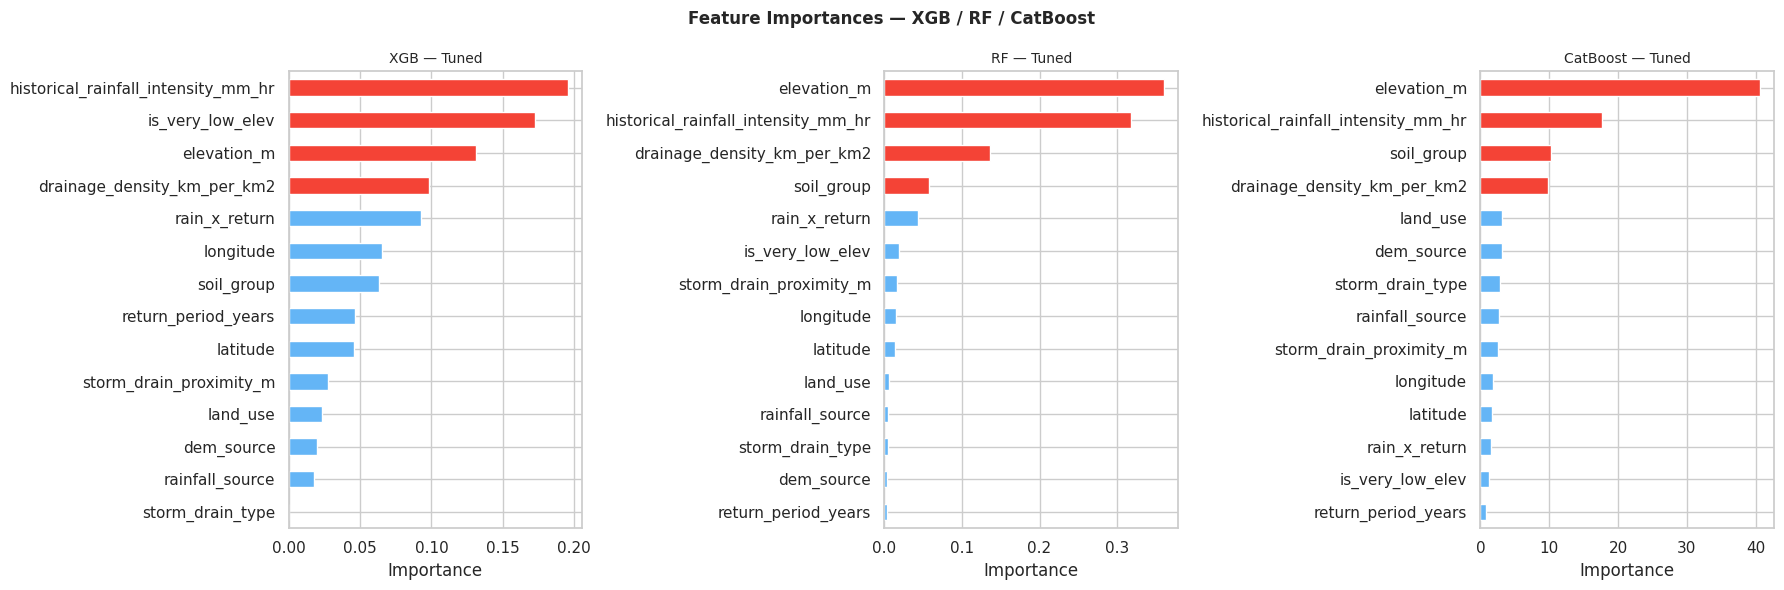

In [59]:
fi_models = [
    (best_xgb_fitted,  ALL_FEATURES, 'XGB — Tuned'),
    (best_rf_fitted,   ALL_FEATURES, 'RF — Tuned'),
    (best_cb_fitted,   ALL_FEATURES, 'CatBoost — Tuned'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (model, feats, title) in zip(axes, fi_models):
    if isinstance(model, CatBoostClassifier):
        imp_vals = model.get_feature_importance()
    else:
        imp_vals = model.feature_importances_
    imp = pd.Series(imp_vals, index=feats).sort_values(ascending=True)
    colors_fi = ['#F44336' if v >= imp.quantile(0.75) else '#64B5F6' for v in imp]
    imp.plot(kind='barh', ax=ax, color=colors_fi)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importances — XGB / RF / CatBoost', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
# ── Final summary ──────────────────────────────────────────────────────────────
best_row  = results_df.loc[results_df['test_f2'].idxmax()]
beat_list = results_df[results_df['beat_baseline']]

print('\n🏆 BEST MODEL (v2):')
print(f'   Model        : {best_row["model"]}  [{best_row["fe_tag"]}]')
print(f'   CV  F2-macro : {best_row["cv_f2"]} ± {best_row["cv_f2_std"]}')
print(f'   CV  Precision: {best_row["cv_precision"]}  | Recall: {best_row["cv_recall"]}  | F1: {best_row["cv_f1_macro"]}')
print(f'   Test F2-macro: {best_row["test_f2"]}'
      f'  {"🎯 BEATS BASELINE" if best_row["beat_baseline"] else "❌ Below baseline"}')
print(f'   Test Precision: {best_row["test_precision"]}  | Recall: {best_row["test_recall"]}  | F1: {best_row["test_f1_macro"]}')
print(f'   Baseline v1  : {BASELINE_F2}')
print(f'   Improvement  : {best_row["test_f2"] - BASELINE_F2:+.4f}')

print(f'\n📋 Models beating baseline ({BASELINE_F2}): {len(beat_list)}')
if len(beat_list) > 0:
    for _, row in beat_list.sort_values('test_f2', ascending=False).iterrows():
        print(
            f'   {row["model"]:<30} [{row["fe_tag"]}]  '
            f'Test F2: {row["test_f2"]:.4f} | P: {row["test_precision"]:.4f} '
            f'R: {row["test_recall"]:.4f} F1: {row["test_f1_macro"]:.4f}'
        )

# Export
results_df.to_csv('results_v2.csv', index=False)
ablation_df.to_csv('ablation_v2.csv', index=False)
print('\n✅ Saved: results_v2.csv, ablation_v2.csv')


🏆 BEST MODEL (v2):
   Model        : HGB — Tuned (Optuna)  [+G3]
   CV  F2-macro : 0.9267 ± 0.0222
   CV  Precision: 0.8881  | Recall: 0.9396  | F1: 0.91
   Test F2-macro: 0.9499  🎯 BEATS BASELINE
   Test Precision: 0.8976  | Recall: 0.9666  | F1: 0.9277
   Baseline v1  : 0.9437
   Improvement  : +0.0062

📋 Models beating baseline (0.9437): 1
   HGB — Tuned (Optuna)           [+G3]  Test F2: 0.9499 | P: 0.8976 R: 0.9666 F1: 0.9277

✅ Saved: results_v2.csv, ablation_v2.csv
